# Aviation Accidents Analysis (1919–2023)

## Introduction

This project analyzes aviation accidents recorded between 1919 and 2023 in order to identify meaningful patterns across time, countries, operators, and aircraft types.

The analysis was developed for the International Alliance for Safe Skies (IASS) and aims to extract useful descriptive insights from the available data, while remaining consistent with the scope and limitations of the dataset.

## Dataset overview

The dataset contains information on nearly 25,000 aviation accidents and includes the following variables:

- `date`: date of the accident  
- `type`: aircraft type  
- `registration`: aircraft registration code  
- `operator`: aircraft operator  
- `fatalities`: number of fatalities  
- `location`: accident location  
- `country`: country of the accident  
- `cat`: ASN occurrence category  
- `year`: year of the accident  

## Main analytical questions

This notebook focuses on the following questions:

- In which countries were the most accidents recorded?  
- Do accidents occur more often on specific days of the week?  
- What can this dataset say about operators and accident patterns?  
- Which aircraft types were associated with the highest number of fatalities?  
- How did accident patterns evolve after September 11, 2001?  

## Scope and limitations

This dataset records aviation accidents, not total flights, fleet size, passenger volumes, or flight hours.  
For this reason, comparisons across countries, operators, and aircraft types should be interpreted as descriptive patterns within the dataset, not as direct measures of real-world safety risk.

## Notebook structure

The notebook is organized into four main parts:

1. Data loading and initial inspection  
2. Data cleaning and feature engineering  
3. Exploratory analysis and visualizations  
4. Final insights and interpretation


### Import and setup

In this section, the core libraries used throughout the notebook are imported and the analysis environment is configured.

The setup includes:

- data manipulation tools
- visualization libraries
- statistical functions used in selected tests
- configuration options to improve readability within the notebook

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path
from IPython.display import display

#### Setup Constants and Standardization Rules

In this section, key constants for the analysis are defined to ensure consistency in processing and reporting:

- **WEEKDAY_ORDER**: standard order of the weekdays for correct temporal analysis.
- **COUNTRY_REPLACEMENTS**: dictionary to standardize country names, avoiding duplicate entries caused by abbreviations or spelling variants.


In [115]:
# Standard order of weekdays for time-based analyses
WEEKDAY_ORDER = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Dictionary to standardize country names before aggregation and mapping
COUNTRY_REPLACEMENTS = {
    "Bosnia": "Bosnia and Herzegovina",
    "Brunei Darussalam": "Brunei",
    "C.A.R.": "Central African Republic",
    "Cape Verde": "Cabo Verde",
    "Curaçao": "Curacao",
    "Czech Rep.": "Czech Republic",
    "D.R. Congo": "Democratic Republic of the Congo",
    "Dem. Rep. Congo": "Democratic Republic of the Congo",
    "Dominican Rep.": "Dominican Republic",
    "Eq. Guinea": "Equatorial Guinea",
    "Ivory Coast": "Côte d'Ivoire",
    "Macedonia": "North Macedonia",
    "N. Korea": "North Korea",
    "P.N. Guinea": "Papua New Guinea",
    "Rep. Congo": "Republic of the Congo",
    "S. Korea": "South Korea",
    "Solomon Isl.": "Solomon Islands",
    "Turks & Caicos": "Turks and Caicos Islands",
    "U.A.E.": "United Arab Emirates",
    "U.K.": "United Kingdom",
    "U.S. Virgin Isl.": "United States Virgin Islands",
    "USA": "United States"
}

#### Dataset Loading

This section loads the dataset file **`aviation-accidents.csv`** by searching a set of possible paths, including the notebook folder. If the file is not found, an error is raised. In Google Colab, if the file is not available, the user is prompted to upload it manually.

In [116]:
EXPECTED_FILE = "aviation-accidents.csv"

candidate_paths = [
    Path(EXPECTED_FILE),
    Path("/content") / EXPECTED_FILE,
    Path("/mnt/data") / EXPECTED_FILE,
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    try:
        from google.colab import files
        print(f"Dataset not found. Please upload '{EXPECTED_FILE}'.")
        uploaded = files.upload()

        if EXPECTED_FILE in uploaded:
            data_path = Path("/content") / EXPECTED_FILE
        elif len(uploaded) == 1:
            uploaded_name = next(iter(uploaded))
            data_path = Path("/content") / uploaded_name
            print(f"Using uploaded file: {uploaded_name}")
        else:
            raise FileNotFoundError(
                f"No valid file uploaded. Expected '{EXPECTED_FILE}'."
            )
    except ModuleNotFoundError:
        print("Dataset file not found.")
        print("Expected file name:", EXPECTED_FILE)
        print("Checked paths:")
        for path in candidate_paths:
            print("-", path)
        raise FileNotFoundError(
            f"The file '{EXPECTED_FILE}' was not found. "
            "Place it in the notebook folder or upload it before running the analysis."
        )

df = pd.read_csv(data_path)

print(f"Dataset loaded successfully: {data_path.resolve()}")
print(f"Shape: {df.shape}")

Dataset loaded successfully: /content/aviation-accidents.csv
Shape: (23967, 9)


### Data loading and first exploration

This section introduces the dataset and provides an initial overview of its structure.

The goal of this first exploration is to:
- inspect the dimensions of the dataset
- review variable names and data types
- identify missing values and obvious inconsistencies
- highlight potential issues that may affect later analyses

This preliminary step is essential to understand the quality of the raw data before proceeding with cleaning, feature engineering, and interpretation.


In [117]:
df.head()

,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


#### Dataset Structure

In this cell, I check the dataset size and column data types.
This initial check helps identify variables that may need conversion or cleaning before the analysis.


In [118]:
print(f"Dataset structure: {df.shape[0]:,} rows and {df.shape[1]} columns before duplicate removal.")
df.info()

Dataset structure: 23,967 rows and 9 columns before duplicate removal.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [119]:
# Check the original values in the date column because some rows contain placeholders like 'date unk.' instead of real dates.
print("First raw values in 'date':")
display(df["date"].head(10))

print("\nRows with 'date unk.':", (df["date"] == "date unk.").sum())

First raw values in 'date':


,date
0,date unk.
1,date unk.
2,date unk.
3,date unk.
4,date unk.
5,date unk.
6,date unk.
7,date unk.
8,date unk.
9,date unk.



Rows with 'date unk.': 61


In [120]:
# Inspect raw operator labels before any cleaning or standardization.
print("Unique raw operators:", df["operator"].nunique(dropna=False))
df["operator"].astype("string").value_counts(dropna=False).head(20)

Unique raw operators: 6018


,count
operator,
USAAF,2604
USAF,1120
RAF,920
US Navy,745
German AF,517
private,299
Aeroflot,198
Unknown,185
Soviet AF,142


In [121]:
# Inspect raw country labels to identify inconsistencies before aggregation.
print("Unique raw countries:", df["country"].nunique(dropna=False))
df["country"].astype("string").value_counts(dropna=False).head(15)

Unique raw countries: 232


,count
country,
USA,4377
Russia,1422
Unknown country,838
U.K.,837
Canada,826
India,700
Brazil,609
France,550
Germany,516


In [122]:
# Count only truly empty values here.
# Text placeholders such as 'unknown' are checked separately
# because isnull() does not treat them as missing values.
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_pct": (df.isnull().sum() / len(df) * 100).round(2)
    })
    .sort_values(by="missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
fatalities,3938,16.43
registration,1548,6.46
location,948,3.96
operator,4,0.02
date,0,0.00
type,0,0.00
country,0,0.00
cat,0,0.00
year,0,0.00


### Missing values summary

The dataset is generally well populated, but some variables contain a non-negligible number of missing values.

In particular:
- `fatalities` has the highest number of missing entries
- `registration` also shows a relevant amount of missing information
- `location` is incomplete in a smaller, but still meaningful, share of records

#### Data quality implications
Missing values affect the scope and reliability of specific analyses:

- analyses based on `fatalities` rely on a reduced subset of records  
- registration-based checks should be interpreted with caution  
- location-level summaries may be partially incomplete  

For this reason, missing data is taken into account throughout the notebook when interpreting charts, rankings, and comparisons.

### Data cleaning and feature construction

After the initial inspection, the next step is to clean and standardize the variables that will be used throughout the analysis.

The main cleaning tasks include:

- converting `year` into a numeric variable  
- parsing valid dates and deriving weekday information  
- standardizing country names  
- cleaning operator names  
- converting `fatalities` into a consistent numeric format  

These steps are necessary because the raw dataset contains several issues that could affect the reliability of the results, including:

- missing values  
- partial or invalid dates  
- non-standard geographic labels  
- inconsistent operator names  
- mixed formats in numeric fields  

The goal of this phase is to create an **analysis-ready dataset** while preserving as much valid information as possible.


#### Duplicate handling


In [123]:
duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows before removal: {duplicate_rows}")
print(f"Dataset shape before duplicate removal: {df.shape}")

if duplicate_rows > 0:
    df = df.drop_duplicates().copy()

print(f"Dataset shape after duplicate removal: {df.shape}")
print(f"Exact duplicate rows after removal: {df.duplicated().sum()}")

Exact duplicate rows before removal: 115
Dataset shape before duplicate removal: (23967, 9)
Dataset shape after duplicate removal: (23852, 9)
Exact duplicate rows after removal: 0


#### Duplicate records

Only **exact duplicate rows** were removed.

Records referring to similar accidents but differing in at least one field were retained, since they may represent **distinct entries** rather than true duplicates.

This choice helps preserve potentially valid historical information while avoiding the risk of removing non-identical records that may still be meaningful for the analysis.

#### Country label exceptions

Some location labels in the dataset do not refer to actual countries.  
These values are treated as missing so they do not distort country-level comparisons and maps.


In [124]:
# These values are not real country names.
# We treat them as missing values so country comparisons and maps are more accurate.
INVALID_COUNTRIES = [
    "Unknown country",
    "?",
    "Atlantic Ocean",
    "Pacific Ocean",
    "Indian Ocean",
    "Arctic Ocean",
    "Mediterranean Sea",
    "Black Sea",
    "Baltic Sea",
    "North Sea",
    "Caspian Sea"
]

# Standardize common operator name variations so the same operator is counted under one name.
OPERATOR_REPLACEMENTS = {
    "Pan Am": "Pan American World Airways",
    "Pan American World Airways / Flight 103": "Pan American World Airways",
    "USAF": "United States Air Force",
    "U.S. Air Force": "United States Air Force",
    "US Navy": "United States Navy",
    "U.S. Navy": "United States Navy",
    "RAF": "Royal Air Force",
    "R.A.F.": "Royal Air Force",
    "USAAF": "United States Army Air Forces",
    "U.S.A.A.F.": "United States Army Air Forces",
    "Air AlgÃ©rie": "Air Algérie",
    "Air-India": "Air India",
    "Sun-Air": "Sun Air"
}

# Use pattern rules to find more versions of the same name.
OPERATOR_REGEX_REPLACEMENTS = {
    r"^U\.?S\.?A\.?F\.?$": "United States Air Force",
    r"^U\.?S\.?\s*Air Force$": "United States Air Force",
    r"^U\.?S\.?\s*Navy$": "United States Navy",
    r"^R\.?A\.?F\.?$": "Royal Air Force",
    r"^U\.?S\.?A\.?A\.?F\.?$": "United States Army Air Forces",
    r"^Pan Am$": "Pan American World Airways"
}

#### Date cleaning helpers
These functions clean the raw accident date and derive the weekday column.


In [125]:
def clean_date_column(date_series):
    """
    Clean the raw accident date column and convert valid values to datetime.

    Parameters:
    date_series: column containing the original date values.

    Returns:
    A cleaned date column. Only complete dates in the format dd-MMM-YYYY
    are kept. Invalid or placeholder values become missing dates (NaT).
    """
    date_tmp = date_series.replace("date unk.", np.nan)
    full_date_mask = date_tmp.astype("string").str.fullmatch(r"\d{2}-[A-Z]{3}-\d{4}", na=False)

    return pd.to_datetime(
        date_tmp.where(full_date_mask),
        format="%d-%b-%Y",
        errors="coerce"
    )


def build_weekday_column(date_clean_series):
    """
    Create an ordered weekday column from a cleaned date column.

    Parameters:
    date_clean_series: cleaned date column.

    Returns:
    An ordered weekday column from Monday to Sunday.
    Missing dates remain missing.
    """
    return pd.Categorical(
        date_clean_series.dt.day_name(),
        categories=WEEKDAY_ORDER,
        ordered=True
    )

#### Country and operator cleaning helpers
These functions standardize country and operator names before analysis.


In [126]:
def clean_country_column(country_series):
    """
    Clean and standardize country names for analysis.

    Parameters:
    country_series: column containing the original country values.

    Returns:
    A cleaned country column with standardized names.
    Invalid geographic labels are treated as missing values.
    """
    cleaned = (
        country_series
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .replace(COUNTRY_REPLACEMENTS)
    )

    cleaned = cleaned.mask(cleaned.isin(INVALID_COUNTRIES))
    return cleaned


def clean_operator_column(operator_series):
    """
    Clean and standardize operator names.

    Parameters:
    operator_series: column containing the original operator values.

    Returns:
    A cleaned operator column with more consistent names.
    Blank and unknown values are treated as missing values.
    Generic labels such as 'private' are kept because they still add information.
    """
    cleaned = (
        operator_series
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("Ã©", "é", regex=False)
        .replace(OPERATOR_REPLACEMENTS)
        .replace(OPERATOR_REGEX_REPLACEMENTS, regex=True)
    )

    cleaned = cleaned.mask(cleaned.str.strip().eq(""), pd.NA)
    cleaned = cleaned.mask(cleaned.str.lower().eq("unknown"), pd.NA)

    return cleaned

#### Fatalities cleaning helper
This function converts the fatalities column into a consistent numeric format.


In [127]:
def clean_fatalities_column(fatalities_series):
    """
    Clean the fatalities column and convert it to a numeric format.

    Parameters:
    fatalities_series: column containing the original fatalities values.

    Returns:
    A cleaned numeric column with nullable integers.
    Combined values such as '5+1' are converted to their total.
    Invalid values are treated as missing.
    """
    cleaned = fatalities_series.astype("string").str.replace(" ", "", regex=False)

    cleaned = cleaned.apply(
        lambda x: str(sum(map(int, x.split("+")))) if pd.notna(x) and "+" in x else x
    )

    return pd.to_numeric(cleaned, errors="coerce").astype("Int64")

#### Summary helper for accident severity
This helper builds aggregated metrics on accidents and fatalities by group.


In [128]:
def build_fatality_summary(df, group_col):
    """
    Create a summary of accidents and fatalities by group.

    Parameters:
    df: dataset containing the cleaned accident records.
    group_col: column used to group the records.

    Returns:
    A summary table with accident counts, known fatalities, total fatalities,
    average fatalities, fatal accidents, and related ratios.
    Some measures use only records with known fatalities.
    """
    summary = (
        df
        .groupby(group_col)
        .agg(
            accidents=(group_col, "size"),
            records_with_known_fatalities=("fatalities_clean", lambda x: x.notna().sum()),
            total_fatalities=("fatalities_clean", lambda x: x.sum(min_count=1)),
            avg_fatalities_per_known_accident=("fatalities_clean", "mean"),
            fatal_accidents=("fatalities_clean", lambda x: (x > 0).sum())
        )
    )

    summary["known_fatalities_share"] = (
        summary["records_with_known_fatalities"] / summary["accidents"]
    )

    summary["fatal_accident_rate_known_only"] = (
        summary["fatal_accidents"] / summary["records_with_known_fatalities"]
    )

    return summary

#### Scope classification helper
This function classifies records into Military and Non-military using operator names.


In [129]:
def classify_record_scope(operator_clean_series):
    """
    Classify records as Military or Non-military based on operator names.

    Parameters:
    operator_clean_series: cleaned operator column.

    Returns:
    A column with two possible values: 'Military' or 'Non-military'.

    Note:
    This is a heuristic classification based on names and keywords,
    so results should be interpreted with caution.
    """
    operator_base = operator_clean_series.fillna("").str.lower().str.strip()

    military_keywords = [
        "air force", "air forces", "armed forces", "army", "navy", "naval",
        "military", "marines", "marine", "luftwaffe",
        "royal air force", "aeronautica militare", "defence", "defense",
        "ministry of defence", "ministry of defense"
    ]

    military_exact_names = {
        "soviet af",
        "soviet air force",
        "red army",
        "united states air force",
        "united states army air forces",
        "united states navy",
        "royal navy",
        "royal australian air force",
        "french air force",
        "indian air force",
        "german af",
        "russian af",
        "indonesian af",
        "spanish af",
        "brazilian af",
        "raaf",
        "rcaf",
        "rnzaf"
    }

    is_military = (
        operator_base.str.contains("|".join(military_keywords), na=False, regex=True)
        | operator_base.isin(military_exact_names)
        | operator_base.str.contains(r"\b[a-z]+ af\b", na=False, regex=True)
        | operator_base.str.contains(r"\braf\b|\busaf\b|\busaaf\b|\braaf\b|\brcaf\b|\brnzaf\b", na=False, regex=True)
    )

    return pd.Series(
        np.where(is_military, "Military", "Non-military"),
        index=operator_clean_series.index,
        dtype="string"
    )

#### Year cleaning and validation
This step checks raw `year` values, handles `unknown` entries, and converts the column to numeric format for time-based analyses.


In [130]:
# Check and convert the year column to a clean numeric format.
year_check = pd.DataFrame({
    "value": df["year"].astype("string").value_counts(dropna=False).index,
    "count": df["year"].astype("string").value_counts(dropna=False).values
})

print("Unique raw values in 'year':", df["year"].nunique(dropna=False))
print("Occurrences of 'unknown':", (df["year"].astype("string") == "unknown").sum())
print("\nAll non-'unknown' values are digits?")
print(
    df.loc[df["year"].astype("string") != "unknown", "year"]
      .astype("string")
      .str.isdigit()
      .value_counts(dropna=False)
)

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

print("\nConverted dtype:", df["year"].dtype)
print("Missing values after conversion:", df["year"].isna().sum())
print("Year range:", df["year"].agg(["min", "max"]).to_dict())

df["year"].dropna().head(10)

Unique raw values in 'year': 106
Occurrences of 'unknown': 61

All non-'unknown' values are digits?
year
True    23791
Name: count, dtype: Int64

Converted dtype: Int64
Missing values after conversion: 61
Year range: {'min': 1919, 'max': 2023}


,year
61,1919
62,1919
63,1920
64,1920
65,1920
66,1920
67,1921
68,1921
69,1921
70,1921


#### Date parsing and valid weekday extraction

Only **complete dates** in the format `dd-MMM-yyyy` were converted to valid datetimes.

Partial, ambiguous, or unknown dates were set to missing (`NaT`) and excluded from analyses that require exact calendar information, such as the **day-of-week distribution**.

This choice improves consistency and avoids introducing artificial patterns based on incomplete temporal data.

#### Date cleaning check


In [131]:
# Apply date cleaning and inspect the cleaned result.
df["date_clean"] = clean_date_column(df["date"])

print("Converted dtype:", df["date_clean"].dtype)
print("Non-null cleaned dates:", df["date_clean"].notna().sum())
print("Missing cleaned dates:", df["date_clean"].isna().sum())

df[["date", "date_clean"]].head(10)

Converted dtype: datetime64[ns]
Non-null cleaned dates: 23303
Missing cleaned dates: 549


,date,date_clean
0,date unk.,NaT
1,date unk.,NaT
2,date unk.,NaT
3,date unk.,NaT
4,date unk.,NaT
5,date unk.,NaT
6,date unk.,NaT
7,date unk.,NaT
8,date unk.,NaT
9,date unk.,NaT


In [132]:
# Check how many rows have a valid full date and inspect examples of excluded raw date values.
valid_dates_pct = (df["date_clean"].notna().mean() * 100).round(2)

print(f"Share of rows with a valid full date: {valid_dates_pct}%")

df.loc[df["date_clean"].isna(), ["date"]].drop_duplicates().head(10)

Share of rows with a valid full date: 97.7%


,date
0,date unk.
84,??-???-1923
109,??-DEC-1928
111,??-FEB-1929
128,??-OCT-1929
165,??-???-1930
240,??-???-1934
290,??-MAY-1936
325,??-???-1936
336,??-MAR-1937


#### Weekday feature creation


In [133]:
# Build the weekday column from cleaned dates and check the result.
df["weekday"] = build_weekday_column(df["date_clean"])

print("Non-null weekdays:", df["weekday"].notna().sum())
print("Missing weekdays:", df["weekday"].isna().sum())

df[["date_clean", "weekday"]].head(10)

Non-null weekdays: 23303
Missing weekdays: 549


,date_clean,weekday
0,NaT,NaN
1,NaT,NaN
2,NaT,NaN
3,NaT,NaN
4,NaT,NaN
5,NaT,NaN
6,NaT,NaN
7,NaT,NaN
8,NaT,NaN
9,NaT,NaN


#### Country cleaning validation


In [134]:
# Apply country cleaning and check the cleaned result.
df["country_clean"] = clean_country_column(df["country"])

print("Non-null cleaned countries:", df["country_clean"].notna().sum())
print("Missing cleaned countries:", df["country_clean"].isna().sum())

df[["country", "country_clean"]].head(15)

Non-null cleaned countries: 22527
Missing cleaned countries: 1325


,country,country_clean
0,Unknown country,<NA>
1,Unknown country,<NA>
2,Unknown country,<NA>
3,Russia,Russia
4,Eritrea,Eritrea
5,Russia,Russia
6,Russia,Russia
7,Russia,Russia
8,Russia,Russia
9,Russia,Russia


In [135]:
# Summarize country data quality before and after cleaning.
country_quality = pd.DataFrame({
    "raw_unique": [df["country"].astype("string").nunique(dropna=False)],
    "clean_unique": [df["country_clean"].astype("string").nunique(dropna=False)],
    "raw_missing": [df["country"].isna().sum()],
    "clean_missing": [df["country_clean"].isna().sum()]
})

country_quality

,raw_unique,clean_unique,raw_missing,clean_missing
0,232,226,0,1325


#### Country standardization

Country standardization reduces label fragmentation from **232 raw values** to **226 cleaned values**.

Invalid, ambiguous, or unknown geographic labels are excluded from country-based analyses to improve consistency in cross-country comparisons.

This step is important because country-level rankings, maps, and aggregated summaries would otherwise be affected by duplicated labels or non-informative entries.
    

#### Operator standardization

The `operator` field is cleaned to reduce label fragmentation (e.g., acronyms, punctuation variants, and encoding issues) before operator-level comparisons.

This step creates `operator_clean`, which is used in the next analyses and in the military/non-military scope classification.


In [136]:
df["operator_clean"] = clean_operator_column(df["operator"])

print("Non-null cleaned operators:", df["operator_clean"].notna().sum())
print("Missing cleaned operators:", df["operator_clean"].isna().sum())

df[["operator", "operator_clean"]].head(20)

Non-null cleaned operators: 23663
Missing cleaned operators: 189


,operator,operator_clean
0,Indonesian AF,Indonesian AF
1,Indonesian AF,Indonesian AF
2,Indonesian AF,Indonesian AF
3,Soviet AF,Soviet AF
4,Soviet AF,Soviet AF
5,Soviet AF,Soviet AF
6,"GUSMP, Directorate of Polar Aviation","GUSMP, Directorate of Polar Aviation"
7,Aeroflot,Aeroflot
8,Russian AF,Russian AF
9,Soviet AF,Soviet AF


### Military vs non-military scope

To better interpret long-term trends, records are also classified as **Military** or **Non-military** based on cleaned operator names.

This is a **rule-based heuristic classification**, not an official ASN field.  
Its purpose is to support broad exploratory comparisons, especially when interpreting historical peaks that may be influenced by wartime or defense-related activity.

#### Methodological note
This classification should **not** be interpreted as a perfectly accurate operational label for every record.

Instead, it should be read as an analytical support variable designed to distinguish, in approximate terms, between records likely related to military operations and those more likely associated with civil aviation.
    

In [137]:
# Create variables to identify military and non-military records.
df["record_scope"] = classify_record_scope(df["operator_clean"])
df["is_military_record"] = df["record_scope"].eq("Military")

df[["operator_clean", "is_military_record", "record_scope"]].head(10)

,operator_clean,is_military_record,record_scope
0,Indonesian AF,True,Military
1,Indonesian AF,True,Military
2,Indonesian AF,True,Military
3,Soviet AF,True,Military
4,Soviet AF,True,Military
5,Soviet AF,True,Military
6,"GUSMP, Directorate of Polar Aviation",False,Non-military
7,Aeroflot,False,Non-military
8,Russian AF,True,Military
9,Soviet AF,True,Military


In [138]:
# Compare operator values before and after cleaning.
operator_quality = pd.DataFrame({
    "raw_unique": [df["operator"].astype("string").nunique(dropna=False)],
    "clean_unique": [df["operator_clean"].astype("string").nunique(dropna=False)],
    "raw_missing": [df["operator"].isna().sum()],
    "clean_missing": [df["operator_clean"].isna().sum()]
})

operator_quality

,raw_unique,clean_unique,raw_missing,clean_missing
0,6018,6015,4,189


In [139]:
# Clean the fatalities column and check the result.
df["fatalities_clean"] = clean_fatalities_column(df["fatalities"])

print("Converted dtype:", df["fatalities_clean"].dtype)
print("Non-null cleaned fatalities:", df["fatalities_clean"].notna().sum())
print("Missing cleaned fatalities:", df["fatalities_clean"].isna().sum())

df[["fatalities", "fatalities_clean"]].head(20)

Converted dtype: Int64
Non-null cleaned fatalities: 20019
Missing cleaned fatalities: 3833


,fatalities,fatalities_clean
0,NaN,<NA>
1,NaN,<NA>
2,NaN,<NA>
3,NaN,<NA>
4,0,0
5,NaN,<NA>
6,NaN,<NA>
7,0,0
8,0,0
9,0,0


In [140]:
# Summarize fatalities data quality after cleaning.
fatalities_quality = pd.DataFrame({
    "raw_missing": [df["fatalities"].isna().sum()],
    "clean_missing": [df["fatalities_clean"].isna().sum()],
    "clean_min": [df["fatalities_clean"].min()],
    "clean_max": [df["fatalities_clean"].max()]
})

fatalities_quality

,raw_missing,clean_missing,clean_min,clean_max
0,3833,3833,0,1692


### Cleaning results and analysis-ready variables

At this stage, the main variables used throughout the notebook have been cleaned and standardized.

In particular:

- `year` has been converted into a numeric variable  
- valid dates have been parsed and used to derive `weekday` information  
- countries and operators have been standardized  
- `fatalities` has been converted into a numeric value whenever possible  

The resulting dataset is now suitable for the main exploratory and analytical sections that follow.

#### Methodological note
This transition is important because the next parts of the notebook rely on variables that are more consistent, more interpretable, and less affected by raw-data formatting issues.

From this point onward, the analysis focuses on **patterns in the cleaned data**, while keeping the previously discussed limitations in mind.

#### Note on temporal variables

This project uses two temporal fields for different analytical purposes:

- **`year`** is used when the analysis only requires annual granularity and can therefore retain a broader set of records.
- **`date_clean`** is used only when the analysis requires a complete and validated calendar date, such as weekday-based patterns or the pre-/post-9/11 comparison.

As a result, analyses based on `date_clean` rely on a more restricted subset of the dataset than those based on `year`. This is a methodological choice made to preserve consistency whenever exact temporal information is required.

### Exploratory analysis

This section provides a first descriptive overview of the cleaned dataset.

Its purpose is to highlight a few broad patterns in accident frequency before moving to the main analytical insights.

In particular, this section focuses on:
- the overall evolution of recorded accidents over time
- the distribution of accidents across weekdays
- early descriptive patterns that help contextualize the more targeted analyses that follow

These exploratory analyses are not the final conclusions of the project, but they provide useful context for interpreting the core results more carefully.


In [141]:
# We compare accidents across weekdays using a simple equal-share reference.
# This helps us see whether some days appear more or less often in the data, but it does not measure real flight risk.
weekday_counts = (
    df["weekday"]
    .value_counts()
    .reindex(WEEKDAY_ORDER, fill_value=0)
)

weekday_percentages = weekday_counts / weekday_counts.sum() * 100

# Reference value under a perfectly uniform distribution across the 7 weekdays.
expected_uniform = weekday_counts.sum() / len(WEEKDAY_ORDER)

pd.DataFrame({
    "accidents": weekday_counts,
    "percentage": weekday_percentages.round(2),
    "diff_vs_uniform": (weekday_counts - expected_uniform).round(0).astype("Int64"),
    "pct_diff_vs_uniform": (((weekday_counts - expected_uniform) / expected_uniform) * 100).round(2)
})

,accidents,percentage,diff_vs_uniform,pct_diff_vs_uniform
weekday,,,,
Monday,3310,14.20,-19,-0.57
Tuesday,3443,14.77,114,3.42
Wednesday,3491,14.98,162,4.87
Thursday,3513,15.08,184,5.53
Friday,3609,15.49,280,8.41
Saturday,3184,13.66,-145,-4.36
Sunday,2753,11.81,-576,-17.30


### Weekday distribution — interpretation

The distribution of recorded accidents across weekdays is fairly balanced overall.

A slightly higher number of accidents appears on **Fridays**, while **Sundays** show a somewhat lower frequency compared with a perfectly uniform distribution.

#### Interpretation note
These differences should be interpreted carefully:

- the dataset records **accidents**, not the total number of flights operated on each weekday  
- it therefore does **not** measure the actual risk per flight  
- the weekday analysis only includes records with a **complete valid date**  

For this reason, the chart is best read as a **descriptive distribution of recorded events**, not as direct evidence that some weekdays are intrinsically more dangerous than others.
    

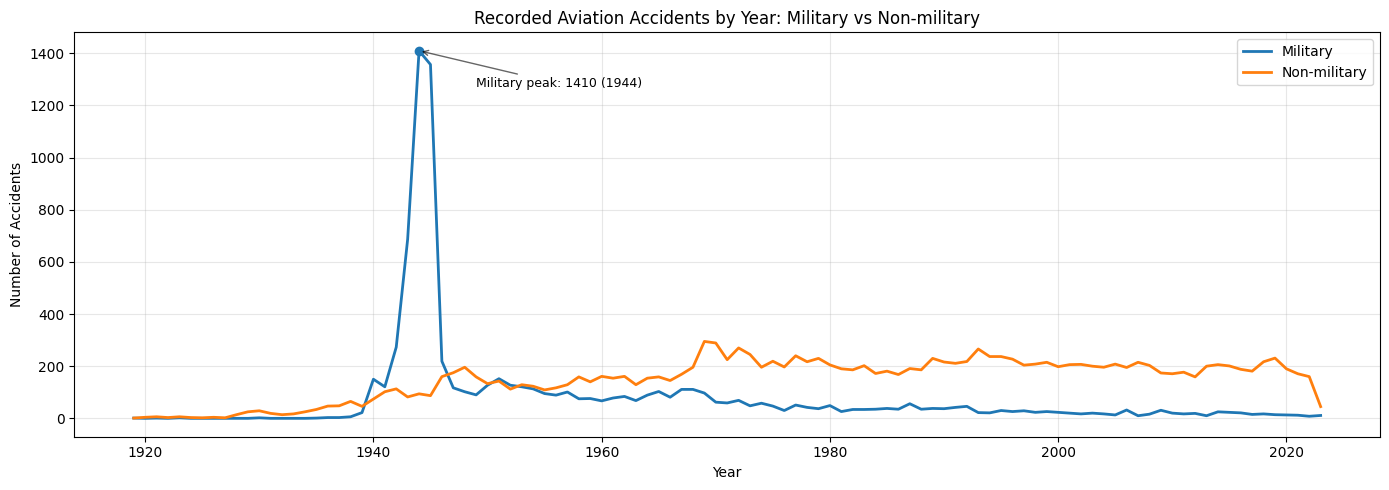

In [142]:
# Compare yearly accident counts by record scope: Military vs Non-military.
# This helps separate broad historical aviation patterns from peaks driven by
# wartime or defense-related activity in the dataset.
accidents_by_scope_year = (
    df.loc[df["year"].notna()]
    .groupby(["year", "record_scope"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(14, 5))

for scope in ["Military", "Non-military"]:
    if scope in accidents_by_scope_year.columns:
        plt.plot(
            accidents_by_scope_year.index,
            accidents_by_scope_year[scope],
            linewidth=2,
            label=scope
        )

if "Military" in accidents_by_scope_year.columns and not accidents_by_scope_year["Military"].empty:
    peak_year = accidents_by_scope_year["Military"].idxmax()
    peak_value = accidents_by_scope_year["Military"].max()

    plt.scatter(peak_year, peak_value, color="tab:blue", zorder=3)
    plt.annotate(
        f"Military peak: {int(peak_value)} ({int(peak_year)})",
        xy=(peak_year, peak_value),
        xytext=(peak_year + 5, peak_value * 0.9),
        arrowprops=dict(arrowstyle="->", alpha=0.6),
        fontsize=9
    )

plt.title("Recorded Aviation Accidents by Year: Military vs Non-military")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Military and non-military trends — interpretation

The sharp spike visible in the 1940s is largely associated with records classified as **Military**.

By contrast, **Non-military** accidents show a more moderate and sustained long-term pattern over time.

This comparison suggests that the full historical series should not be interpreted as a homogeneous trend: part of the variation is strongly influenced by military-related records, especially around the 1940s.
    

## Historical trends and data completeness

This section examines long-term accident trends together with data completeness.

Changes over time may reflect not only real shifts in aviation safety, but also differences in reporting, record coverage, and historical context. For this reason, the following charts should be read as descriptive trends shaped in part by the structure of the dataset.

#### Trend computation by record scope


In [143]:
# Count the number of recorded accidents for each year.
incidents_per_year = df["year"].dropna().value_counts().sort_index()

incidents_per_year.rename_axis("year").reset_index(name="Recorded accidents")

,year,Recorded accidents
0,1919,2
1,1920,4
2,1921,7
3,1922,3
4,1923,8
...,...,...
100,2019,245
101,2020,203
102,2021,183
103,2022,168


#### Long-run trend setup (2023 exclusion)


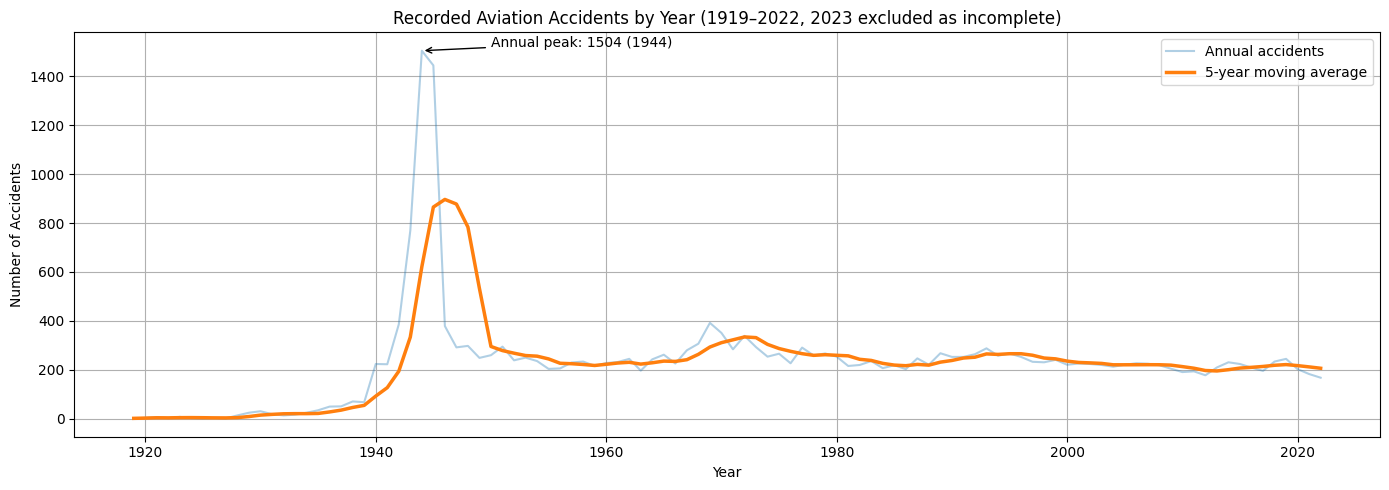

In [144]:
# Exclude 2023 from the long-run trend because the year appears incomplete in the dataset.
# This avoids creating an artificial drop at the end of the series.
incidents_per_year_complete = incidents_per_year.loc[incidents_per_year.index <= 2022]

# Use a 5-year moving average to reduce year-to-year fluctuations
# and make the long-term trend easier to see.
accidents_trend = (
    incidents_per_year_complete
    .rolling(window=5, min_periods=1)
    .mean()
)

peak_year = incidents_per_year_complete.idxmax()
peak_value = incidents_per_year_complete.max()

plt.figure(figsize=(14, 5))

plt.plot(
    incidents_per_year_complete.index,
    incidents_per_year_complete.values,
    alpha=0.35,
    linewidth=1.5,
    label="Annual accidents"
)

plt.plot(
    accidents_trend.index,
    accidents_trend.values,
    linewidth=2.5,
    label="5-year moving average"
)

plt.annotate(
    f"Annual peak: {int(peak_value)} ({int(peak_year)})",
    xy=(peak_year, peak_value),
    xytext=(peak_year + 6, peak_value + 15),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Recorded Aviation Accidents by Year (1919–2022, 2023 excluded as incomplete)")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Yearly accident trends

This chart shows the total number of recorded accidents by year (2023 excluded as incomplete), together with a 5-year moving average to smooth short-term volatility.

The 1944 peak is clearly visible in the annual series, while the moving average highlights the broader long-term pattern.

#### Methodological note

This is an aggregate trend that combines military and non-military records.
For this reason, it should be interpreted as an overall historical pattern of recorded accidents, not as a civil-aviation-only trend.


#### Moving to decade-level analysis

From this point, we move from yearly trends to data quality by decade.
We create the `decade` variable to compare coverage and completeness across different historical periods.


In [145]:
df["decade"] = (df["year"] // 10) * 10

# Build a decade-level quality check to verify whether historical comparisons
# are influenced by missing dates, locations, or fatalities in older periods.
decade_summary = (
    df.dropna(subset=["decade"])
      .groupby("decade")
      .agg(
          accidents=("year", "size"),
          valid_date_pct=("date_clean", lambda s: s.notna().mean() * 100),
          valid_location_pct=("location", lambda s: s.notna().mean() * 100),
          valid_fatalities_pct=("fatalities_clean", lambda s: s.notna().mean() * 100)
      )
      .reset_index()
)

decade_summary.head(15)

,decade,accidents,valid_date_pct,valid_location_pct,valid_fatalities_pct
0,1910,2,100.000000,100.000000,100.000000
1,1920,72,94.444444,97.222222,90.277778
2,1930,381,96.850394,96.850394,83.727034
3,1940,5768,98.092926,92.753121,55.721221
4,1950,2370,99.071730,96.329114,89.535865
5,1960,2612,98.124043,95.903522,88.514548
6,1970,2831,97.244790,95.407983,90.957259
7,1980,2291,96.464426,95.591445,90.571803
8,1990,2541,97.166470,98.583235,95.277450
9,2000,2201,98.182644,99.500227,99.091322


### Data completeness by decade

Data completeness is not uniform across the historical span of the dataset.

As a result, long-term trends may reflect not only changes in accident patterns, but also differences in reporting quality, record availability, and documentation consistency. Earlier decades should therefore be interpreted more cautiously, while recent decades are generally more reliable for comparison.

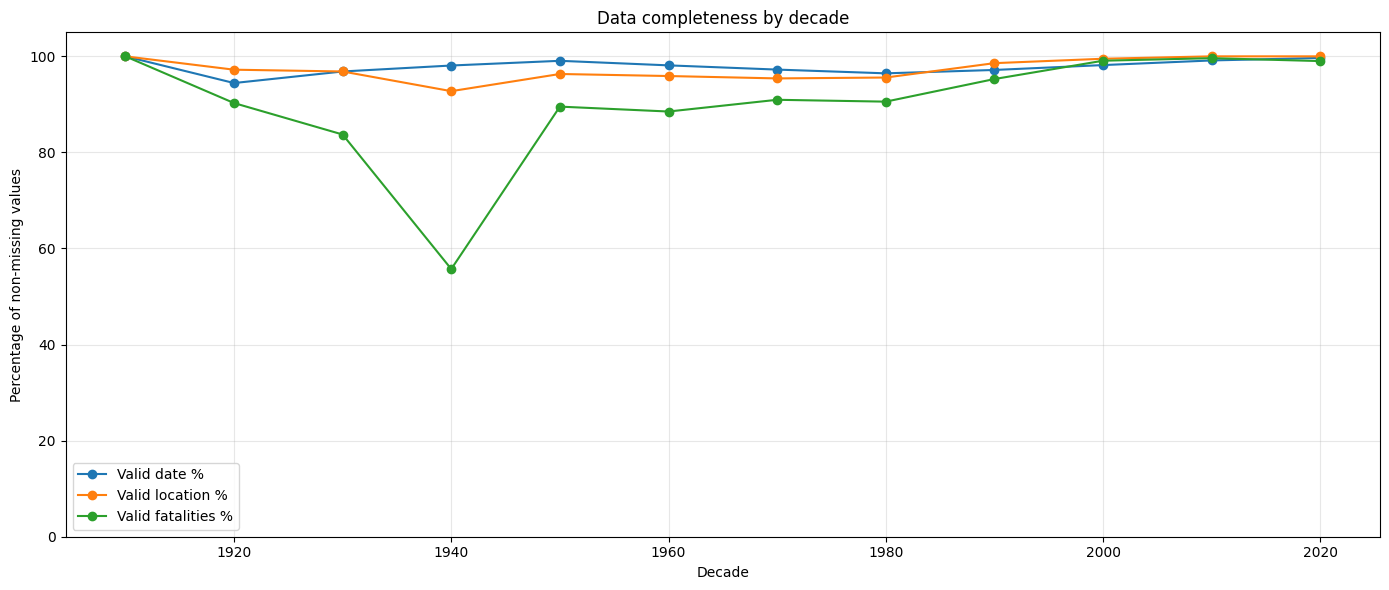

In [146]:
# Compare data completeness across decades to see where missing values are more common.
plt.figure(figsize=(14, 6))

plt.plot(decade_summary["decade"], decade_summary["valid_date_pct"], marker="o", label="Valid date %")
plt.plot(decade_summary["decade"], decade_summary["valid_location_pct"], marker="o", label="Valid location %")
plt.plot(decade_summary["decade"], decade_summary["valid_fatalities_pct"], marker="o", label="Valid fatalities %")

plt.title("Data completeness by decade")
plt.xlabel("Decade")
plt.ylabel("Percentage of non-missing values")
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Data completeness by decade — interpretation**

The chart shows that data completeness is generally high for `date` and `location` across most decades, while `fatalities` is more uneven in older periods, with a marked drop in the 1940s.

From recent decades onward, completeness improves and approaches full coverage, making comparisons more stable.

#### Methodological note

Long-term comparisons should always be interpreted together with data coverage, especially for earlier decades.  
The 2020s should also be read with caution because the decade is not yet complete.


### Accidents and fatalities by decade

After assessing data completeness, this section compares two dimensions together:
the number of recorded accidents and total fatalities by decade.
This helps separate event frequency from event severity.


In [147]:
accidents_by_decade = (
    df.dropna(subset=["decade"])
      .groupby("decade")
      .size()
      .sort_index()
)

# Sum fatalities by decade to compare not only how many accidents happened,
# but also how serious they were in each period.
fatalities_by_decade = (
    df.dropna(subset=["decade", "fatalities_clean"])
      .groupby("decade")["fatalities_clean"]
      .sum()
      .sort_index()
)

# Combine accident counts and total fatalities into a single decade-level table
# so frequency and severity can be compared side by side.
decade_trends = pd.DataFrame({
    "accidents": accidents_by_decade,
    "total_fatalities": fatalities_by_decade
}).fillna(0)

decade_trends

,accidents,total_fatalities
decade,,
1910,2,15
1920,72,140
1930,381,1330
1940,5768,17699
1950,2370,14488
1960,2612,19899
1970,2831,22087
1980,2291,18093
1990,2541,16804


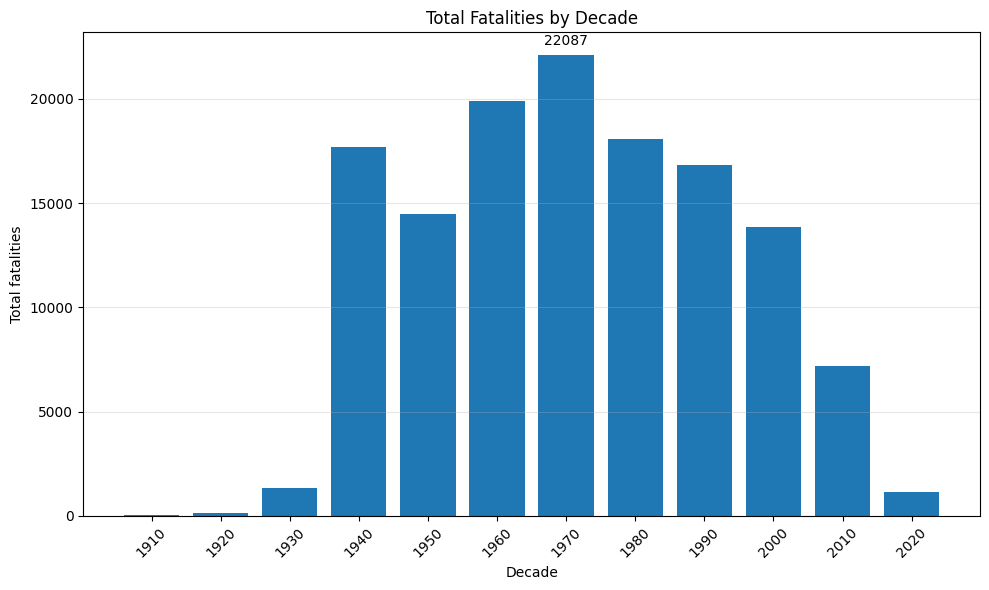

In [148]:
# Highlight the decade with the highest total fatalities to make the peak
# immediately visible in the chart.
plt.figure(figsize=(10, 6))

bars = plt.bar(
    fatalities_by_decade.index.astype(int).astype(str),
    fatalities_by_decade.values
)

# Find the decade with the highest total fatalities.
max_idx = fatalities_by_decade.values.argmax()
max_bar = bars[max_idx]
max_value = fatalities_by_decade.values[max_idx]

plt.text(
    max_bar.get_x() + max_bar.get_width() / 2,
    max_value + 500,
    str(max_value),
    ha="center"
)

plt.title("Total Fatalities by Decade")
plt.xlabel("Decade")
plt.ylabel("Total fatalities")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Fatalities by decade — interpretation**

The total number of fatalities does not perfectly mirror the number of recorded events.

Some decades stand out not only because more events were recorded, but also because of the overall human cost associated with the events recorded in those periods.

This reinforces an important analytical distinction:

- the number of recorded events shows how often events appear in the dataset
- the number of fatalities shows how severe those events were in human terms

For this reason, both measures should be considered together when interpreting long-term patterns in the dataset.

#### Methodological note

The most recent decade should be interpreted more cautiously, because it is not yet complete and may not be fully comparable with earlier decades.

### Supporting exploratory block — Understanding the `cat` variable

Before moving to the core insights, this section briefly examines `cat`, the **ASN occurrence category** assigned to each event.

It helps explain how events are classified in the dataset, how categories are distributed, and how they differ in both frequency and severity.

`cat` is recorded as a short technical code, such as `A1`, `A2`, `C1`, or `H2`, describing the type of occurrence.

To make interpretation easier, the analysis considers:
- the original detailed codes
- a broader grouped classification based on the leading letter

This makes `cat` a useful descriptive dimension for exploratory analysis.

In [149]:
# Group ASN codes into simpler main categories using their first letter.
cat_clean = df["cat"].astype("string").str.strip()

df["cat_main"] = cat_clean.str[0].str.upper()

# Map the first ASN code letter to a readable main occurrence category.
cat_main_map = {
    "A": "Accident",
    "I": "Incident",
    "H": "Hijacking",
    "C": "Criminal occurrence",
    "O": "Other occurrence",
    "U": "Unknown occurrence"
}

df["cat_main_label"] = df["cat_main"].map(cat_main_map)

# Handle missing or unmatched codes so every record gets a clear label.
df.loc[cat_clean.isna(), "cat_main_label"] = "Missing"
df.loc[cat_clean.notna() & df["cat_main_label"].isna(), "cat_main_label"] = "Other / unmapped"

# Quick validation
df[["cat", "cat_main", "cat_main_label"]].head(10)

,cat,cat_main,cat_main_label
0,U1,U,Unknown occurrence
1,U1,U,Unknown occurrence
2,U1,U,Unknown occurrence
3,A1,A,Accident
4,A1,A,Accident
5,U1,U,Unknown occurrence
6,A1,A,Accident
7,A2,A,Accident
8,A1,A,Accident
9,O1,O,Other occurrence


In [150]:
# Count records in each main ASN category, including missing values.
df["cat_main_label"] \
    .value_counts(dropna=False) \
    .rename_axis("cat_main_label") \
    .reset_index(name="records") \
    .style.hide(axis="index")

cat_main_label,records
Accident,19812
Criminal occurrence,1265
Other occurrence,1098
Hijacking,1091
Unknown occurrence,571
Incident,15


In [151]:
# Count the original ASN codes to see which detailed event codes appear most often
# before grouping them into broader categories.
cat_overview = (
    df["cat"]
    .value_counts(dropna=False)
    .rename_axis("cat")
    .reset_index(name="records")
)

cat_overview["percentage"] = (
    cat_overview["records"] / cat_overview["records"].sum() * 100
).round(2)

cat_overview.style.hide(axis="index")

cat,records,percentage
A1,17318,72.610000
A2,2494,10.460000
C1,1181,4.950000
H2,1049,4.400000
O1,1033,4.330000
U1,571,2.390000
C2,84,0.350000
O2,65,0.270000
H1,42,0.180000
I2,12,0.050000


In [152]:
# Count records in the main ASN categories to show a simpler overview
# than the original detailed ASN codes.
cat_main_overview = (
    df["cat_main_label"]
    .value_counts(dropna=False)
    .rename_axis("cat_main_label")
    .reset_index(name="records")
)

cat_main_overview["percentage"] = (
    cat_main_overview["records"] / cat_main_overview["records"].sum() * 100
).round(2)

cat_main_overview.style.hide(axis="index")

cat_main_label,records,percentage
Accident,19812,83.060000
Criminal occurrence,1265,5.300000
Other occurrence,1098,4.600000
Hijacking,1091,4.570000
Unknown occurrence,571,2.390000
Incident,15,0.060000


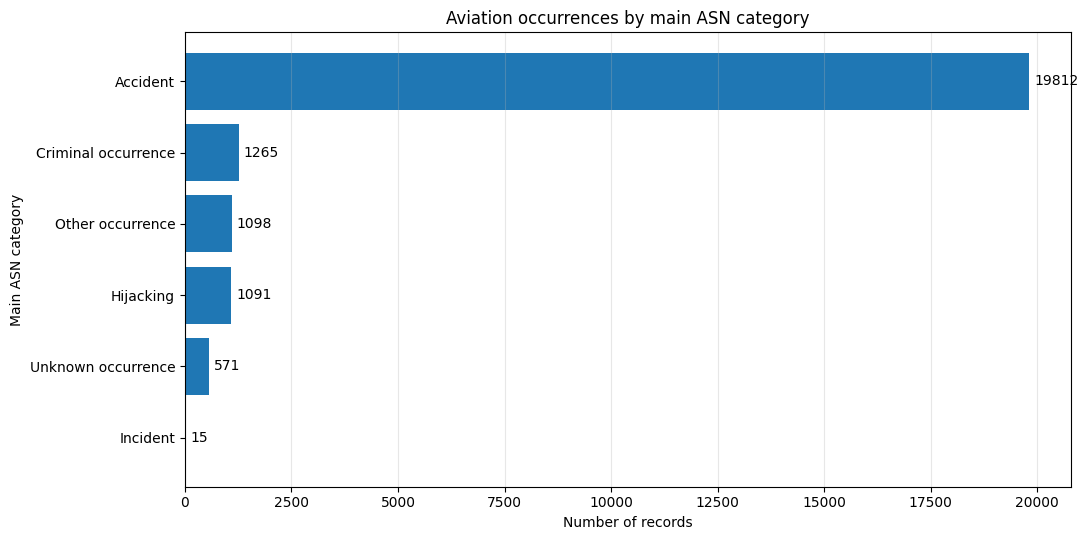

In [153]:
# Plot the main ASN categories to show which grouped event types are most common
# and how much the dataset is dominated by the "Accident" category.
cat_main_counts = df["cat_main_label"].value_counts().sort_values()

plt.figure(figsize=(11, 5.5))

bars = plt.barh(
    cat_main_counts.index,
    cat_main_counts.values
)

# Add the count next to each bar to make the size difference easier to read.
for bar, value in zip(bars, cat_main_counts.values):
    plt.text(
        value + 120,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center"
    )

plt.title("Aviation occurrences by main ASN category")
plt.xlabel("Number of records")
plt.ylabel("Main ASN category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**`cat` grouped distribution — interpretation**

The grouped distribution is strongly dominated by the **Accident** category, which represents most of the recorded occurrences in the dataset.

All other main ASN categories — such as **Incident**, **Hijacking**, **Security-related occurrences**, and **Ground damage** — are much less frequent.

#### Interpretation note
This pattern suggests that the dataset is mainly centered on **accident events in the strict sense**, while other types of aviation occurrences play a more limited role.

As a result, most of the broader trends observed in the notebook should be interpreted mainly as patterns in **recorded accident history**, rather than as a balanced view of all aviation occurrence types.

#### Fatalities by detailed ASN category

After analyzing category distribution, we now move to severity. We compare detailed `cat` codes by total and average fatalities, using only records with known fatalities.

The summary table below compares each detailed ASN code across multiple dimensions, including frequency, total fatalities, average fatalities, and the share of fatal records.


In [154]:
# Use only records with a valid ASN category and known fatalities
# so categories can be compared using observed fatality values only.
cat_fatalities = df.dropna(subset=["cat", "fatalities_clean"]).copy()

In [155]:
# Create a summary for each ASN code to compare how often it appears,
# how many fatalities it caused, and how severe it is on average.
cat_summary = (
    cat_fatalities
    .groupby("cat")
    .agg(
        accidents=("cat", "size"),
        records_with_known_fatalities=("fatalities_clean", lambda x: x.notna().sum()),
        fatal_accidents=("fatalities_clean", lambda x: (x > 0).sum()),
        total_fatalities=("fatalities_clean", lambda x: x.sum(min_count=1)),
        avg_fatalities_per_known_record=("fatalities_clean", "mean")
    )
)

cat_summary["accidents_pct"] = (
    cat_summary["accidents"] / cat_summary["accidents"].sum() * 100
)

cat_summary["fatalities_pct"] = (
    cat_summary["total_fatalities"] / cat_summary["total_fatalities"].sum() * 100
)

# Measure how often records in each ASN category include at least one fatality.
cat_summary["fatal_accident_rate"] = (
    cat_summary["fatal_accidents"] / cat_summary["records_with_known_fatalities"]
)

cat_summary = cat_summary.sort_values("total_fatalities", ascending=False)

cat_summary.round({
    "accidents_pct": 2,
    "fatalities_pct": 2,
    "avg_fatalities_per_known_record": 2,
    "fatal_accident_rate": 2
})

,accidents,records_with_known_fatalities,fatal_accidents,total_fatalities,avg_fatalities_per_known_record,accidents_pct,fatalities_pct,fatal_accident_rate
cat,,,,,,,,
A1,14352,14352,8507,119680,8.34,71.69,90.17,0.59
C1,966,966,539,8983,9.3,4.83,6.77,0.56
H1,42,42,26,3592,85.52,0.21,2.71,0.62
H2,1045,1045,112,181,0.17,5.22,0.14,0.11
A2,2471,2471,82,155,0.06,12.34,0.12,0.03
O1,941,941,21,75,0.08,4.70,0.06,0.02
C2,84,84,25,54,0.64,0.42,0.04,0.3
O2,64,64,2,2,0.03,0.32,0.0,0.03
I1,3,3,0,0,0.0,0.01,0.0,0.0


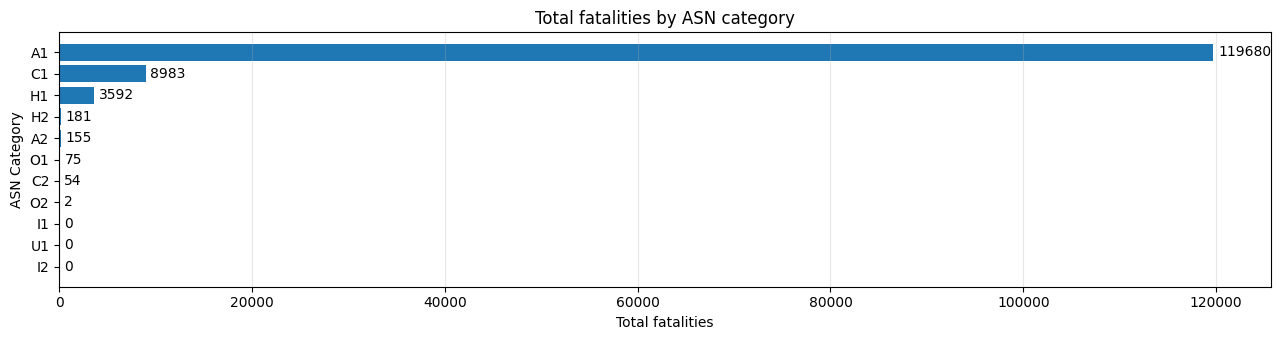

In [156]:
# Extract total fatalities by ASN category for plotting, so the chart focuses
# on relative human impact across occurrence types.
cat_total_fatalities = cat_summary["total_fatalities"].sort_values()

# Plot total fatalities by ASN category and label each bar to make the large
# gap between categories immediately visible.
plt.figure(figsize=(13, 3.5))

bars = plt.barh(
    cat_total_fatalities.index,
    cat_total_fatalities.values
)

for bar, value in zip(bars, cat_total_fatalities.values):
    plt.text(
        value + 500,
        bar.get_y() + bar.get_height() / 2,
        str(int(value)),
        va="center"
    )

plt.title("Total fatalities by ASN category")
plt.xlabel("Total fatalities")
plt.ylabel("ASN Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Fatalities by detailed ASN category — interpretation**

ASN category **A1** accounts for by far the highest total number of fatalities in the dataset, while all other detailed categories contribute much less to the overall total.

#### Interpretation note
This result should be read as a descriptive pattern in the available data, based on:

- recorded `fatalities` values  
- detailed ASN category codes stored in `cat`  

Because the substantive meaning of each code depends on the **external ASN classification scheme**, the chart is most useful as a way to compare the relative weight of categories within the dataset, rather than as a standalone explanation of accident causes or mechanisms.


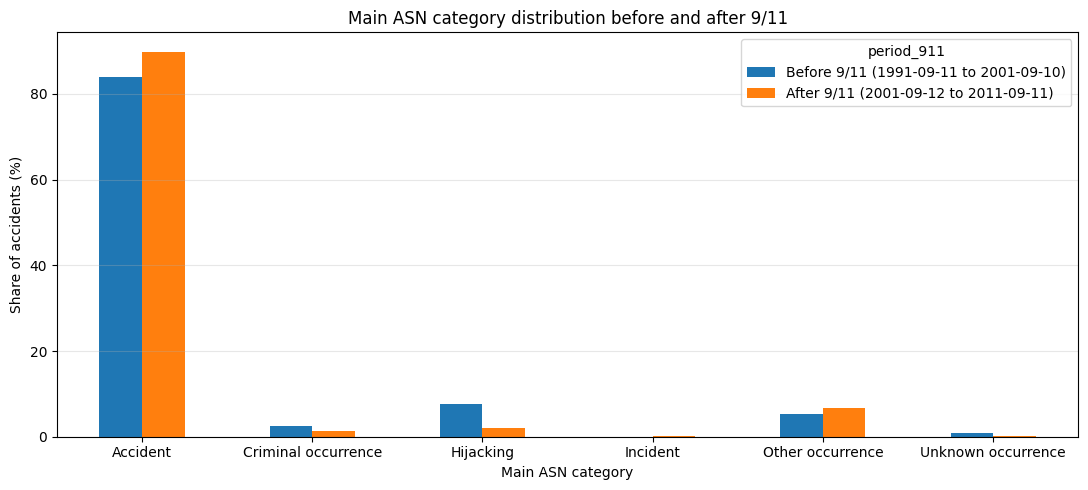

,period_911,cat_main_label,accidents,share_pct
6,Before 9/11 (1991-09-11 to 2001-09-10),Accident,2030,83.85
8,Before 9/11 (1991-09-11 to 2001-09-10),Hijacking,182,7.52
9,Before 9/11 (1991-09-11 to 2001-09-10),Other occurrence,126,5.20
7,Before 9/11 (1991-09-11 to 2001-09-10),Criminal occurrence,63,2.60
10,Before 9/11 (1991-09-11 to 2001-09-10),Unknown occurrence,20,0.83
0,After 9/11 (2001-09-12 to 2011-09-11),Accident,1916,89.87
4,After 9/11 (2001-09-12 to 2011-09-11),Other occurrence,142,6.66
2,After 9/11 (2001-09-12 to 2011-09-11),Hijacking,44,2.06
1,After 9/11 (2001-09-12 to 2011-09-11),Criminal occurrence,26,1.22
3,After 9/11 (2001-09-12 to 2011-09-11),Incident,2,0.09


In [157]:
# Compare the distribution of main ASN categories before and after 9/11
# using the same symmetric windows adopted in the core 9/11 insight.
# The event day (2001-09-11) is excluded from both periods.

before_start_911 = pd.Timestamp("1991-09-11")
event_day_911 = pd.Timestamp("2001-09-11")
after_end_911 = pd.Timestamp("2011-09-11")

cat_911 = (
    df.dropna(subset=["date_clean", "cat_main_label"])
      .loc[
          lambda x: (
              ((x["date_clean"] >= before_start_911) & (x["date_clean"] < event_day_911))
              |
              ((x["date_clean"] > event_day_911) & (x["date_clean"] <= after_end_911))
          )
      ]
      .assign(
          period_911=lambda x: np.where(
              x["date_clean"] < event_day_911,
              "Before 9/11 (1991-09-11 to 2001-09-10)",
              "After 9/11 (2001-09-12 to 2011-09-11)"
          )
      )
)

cat_911_summary = (
    cat_911.groupby(["period_911", "cat_main_label"])
           .size()
           .reset_index(name="accidents")
)

# Convert counts into percentages so the category mix can be compared fairly across the two periods.
cat_911_summary["share_pct"] = (
    cat_911_summary["accidents"]
    / cat_911_summary.groupby("period_911")["accidents"].transform("sum")
    * 100
).round(2)

cat_911_pivot = (
    cat_911_summary
    .pivot(index="cat_main_label", columns="period_911", values="share_pct")
    .fillna(0)
)

desired_order = [
    "Before 9/11 (1991-09-11 to 2001-09-10)",
    "After 9/11 (2001-09-12 to 2011-09-11)"
]

cat_911_pivot = cat_911_pivot.reindex(columns=desired_order)

cat_911_pivot.plot(kind="bar", figsize=(11, 5))
plt.title("Main ASN category distribution before and after 9/11")
plt.ylabel("Share of accidents (%)")
plt.xlabel("Main ASN category")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

cat_911_summary["period_911"] = pd.Categorical(
    cat_911_summary["period_911"],
    categories=desired_order,
    ordered=True
)

cat_911_summary.sort_values(["period_911", "share_pct"], ascending=[True, False])


**cat distribution before and after 9/11 - interpretation**

The comparison between the pre-9/11 period (1991-09-11 to 2001-09-10) and the post-9/11 period (2001-09-12 to 2011-09-11) shows that the dataset remains strongly dominated by the **Accident** category in both periods.

After 9/11, the relative share of **Accident** records increases (from 83.85% to 89.87%), while **Hijacking** declines markedly (from 7.52% to 2.06%). **Criminal occurrence** also decreases (from 2.60% to 1.22%), whereas **Other occurrence** remains secondary but slightly higher (from 5.20% to 6.66%).

#### Interpretation note

This comparison adds a temporal perspective to the `cat` analysis and helps show that the composition of recorded aviation occurrences changed after 9/11, not only in total volume but also in the relative importance of specific occurrence categories.

As a result, the `cat` variable is useful not only for describing how events are classified, but also for identifying how the structure of recorded aviation events evolved across major historical periods.


## Core insights

This section presents the **main findings** of the analysis, focusing on the questions most directly connected to the project brief.

Unlike the previous exploratory blocks, the following sections are organized around the **core analytical questions** of the project and are designed to provide the most relevant descriptive insights supported by charts and interpretation.

Each insight is discussed with attention to both:
- the pattern observed in the cleaned data
- the methodological limits that affect interpretation
  

## Insight 1 — In which countries were the most accidents recorded?

This first insight examines the geographical distribution of recorded aviation accidents.

The goal is to identify which countries appear most often in the dataset and to assess whether accident records are widely spread or concentrated in a smaller number of countries.

#### Interpretation note

This ranking shows recorded accidents by country, not aviation safety levels.

Differences across countries may also reflect:
- the size of the national aviation system
- differences in reporting coverage
- the scale of aviation activity over time

## Insight 1 — interpretation

Recorded accidents are concentrated in a relatively small number of countries.

The leading countries account for a substantial share of records with a known country, suggesting that the geographical distribution is not uniform.

#### Important caution

This result should not be read as a direct comparison of national aviation safety.

The ranking is based on accident counts only and does not include exposure factors such as:
- number of flights
- traffic volume
- fleet size

## Supporting comparison — Countries with the highest total fatalities

To complement accident counts, it is also useful to examine total fatalities by country.

This helps distinguish between countries with many recorded accidents and countries where accidents were more severe.

#### Country ranking computation (operational step)

In this block, I prepare the geographic ranking for Insight 1.
I use only records with a valid standardized country (`country_clean`) to avoid distortions from missing or non-standard labels.


In [158]:
# Restrict the ranking to records with a valid standardized country label.
# This keeps the comparison reliable by excluding entries that cannot be assigned to a country consistently.
country_valid = df["country_clean"].dropna()
country_counts = country_valid.value_counts()
top_10_countries = country_counts.head(10).sort_values(ascending=True)

country_total = len(country_valid)

top_10_countries_summary = pd.DataFrame({
    "accidents": top_10_countries,
    "percentage_of_valid_country_records": ((top_10_countries / country_total) * 100).round(2)
})

top_10_countries_summary

,accidents,percentage_of_valid_country_records
country_clean,,
Colombia,457,2.03
Germany,513,2.28
China,514,2.28
France,550,2.44
Brazil,609,2.7
India,700,3.11
Canada,825,3.66
United Kingdom,837,3.72
Russia,1418,6.29


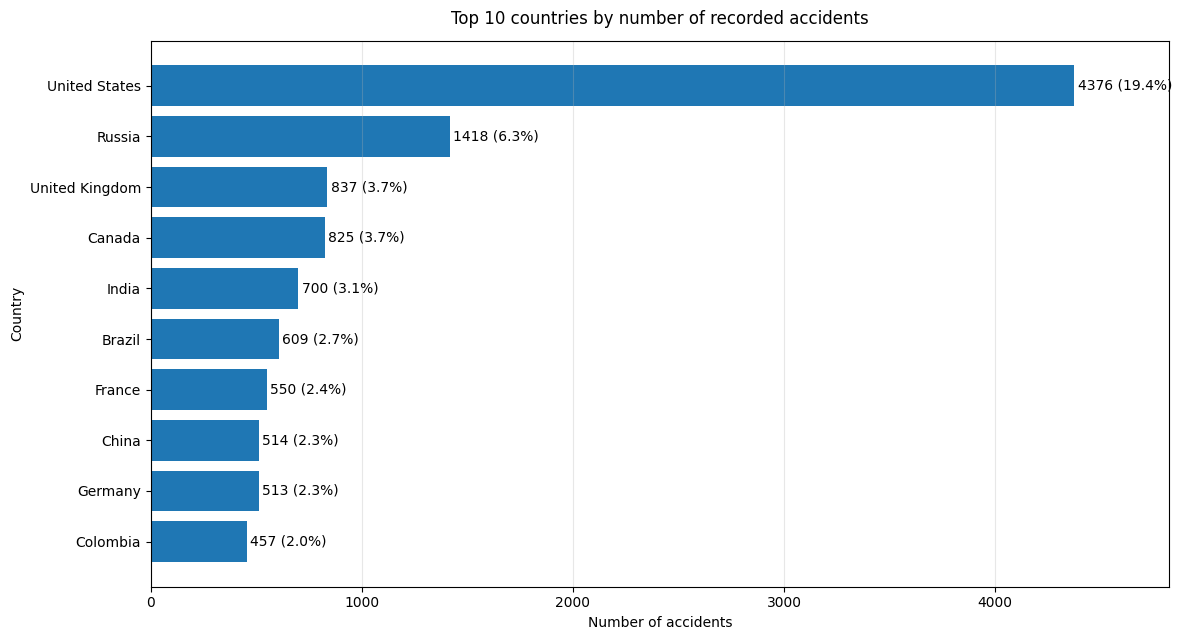

In [159]:
# Show the 10 countries with the most accidents.
# Only records with a known country are included, so the comparison is more reliable.
plt.figure(figsize=(12, 6.5))

bars = plt.barh(
    top_10_countries.index,
    top_10_countries.values
)

# Total number of accidents with a known country.
# This is used to compute the percentage share of each country.
total_known_country = df["country_clean"].dropna().shape[0]

# Extend the x-axis a bit so the labels on the right stay inside the figure.
x_max = top_10_countries.max()
plt.xlim(0, x_max + 450)

# Add value + percentage for every bar.
for bar, value in zip(bars, top_10_countries.values):
    pct = (value / total_known_country) * 100
    plt.text(
        value + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{value} ({pct:.1f}%)",
        va="center"
    )

plt.title("Top 10 countries by number of recorded accidents", pad=12)
plt.xlabel("Number of accidents")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### Key concentration metrics by country

This cell computes summary concentration indicators after the Top 10 chart.
It identifies the leading country and quantifies how much of the total is concentrated in the top 3 and top 10 countries.


In [160]:
# Identify the country with the highest number of recorded accidents.
top_country = country_counts.idxmax()
top_country_accidents = country_counts.max()
top_country_share = round((top_country_accidents / country_total) * 100, 2)

# This estimates cumulative concentration in the main ranking groups.
top_3_share = round((country_counts.head(3).sum() / country_total) * 100, 2)
top_10_share = round((country_counts.head(10).sum() / country_total) * 100, 2)

print(
    f"{top_country} recorded the highest number of accidents in the dataset: "
    f"{top_country_accidents} cases ({top_country_share}% of records with a valid country attribution). "
    f"More broadly, the top 3 countries account for {top_3_share}% of valid country-attributed records, "
    f"while the top 10 countries account for {top_10_share}%."
)

United States recorded the highest number of accidents in the dataset: 4376 cases (19.43% of records with a valid country attribution). More broadly, the top 3 countries account for 29.44% of valid country-attributed records, while the top 10 countries account for 47.94%.


## Insight 1 — interpretation

The country ranking shows a clear concentration of recorded accidents in a relatively small number of countries.

In particular, the leading countries account for a meaningful share of all records with a valid country attribution, which suggests that the geographical distribution of accidents in the dataset is far from uniform.

#### Methodological note
This result should not be interpreted as a direct measure of aviation safety.

The ranking is based on **historical accident counts only** and does not account for exposure variables such as:

- number of flights  
- traffic volume  
- fleet size  
- long-term scale of aviation activity  

For this reason, the chart is best read as a **descriptive concentration of recorded accidents by country**, not as a true safety comparison between national aviation systems.


### Supporting comparison — Countries with the highest total fatalities

This comparison complements **Insight 1** by shifting the focus from the **number of recorded accidents** to the **total number of fatalities**.

While accident counts describe how frequently events appear in the dataset, fatalities capture a different dimension: the **overall human cost** associated with those events in each country.

#### Why this comparison is useful
Looking at both measures together helps distinguish between:

- countries with many recorded accidents  
- countries associated with the highest cumulative loss of life  

This distinction is important because **frequency** and **severity** do not always coincide, and they may lead to different geographical rankings.


In [161]:
# Aggregate total fatalities by country to compare cumulative human impact,
# not just the number of recorded accidents.
country_fatalities = (
    df.dropna(subset=["country_clean", "fatalities_clean"])
      .groupby("country_clean", as_index=False)["fatalities_clean"]
      .sum()
      .sort_values("fatalities_clean", ascending=False)
)

country_fatalities.head(10)

,country_clean,fatalities_clean
213,United States,19305
165,Russia,9966
28,Brazil,3523
93,India,3505
71,France,3426
94,Indonesia,3360
44,Colombia,3325
41,China,2870
185,Spain,2785
212,United Kingdom,2631


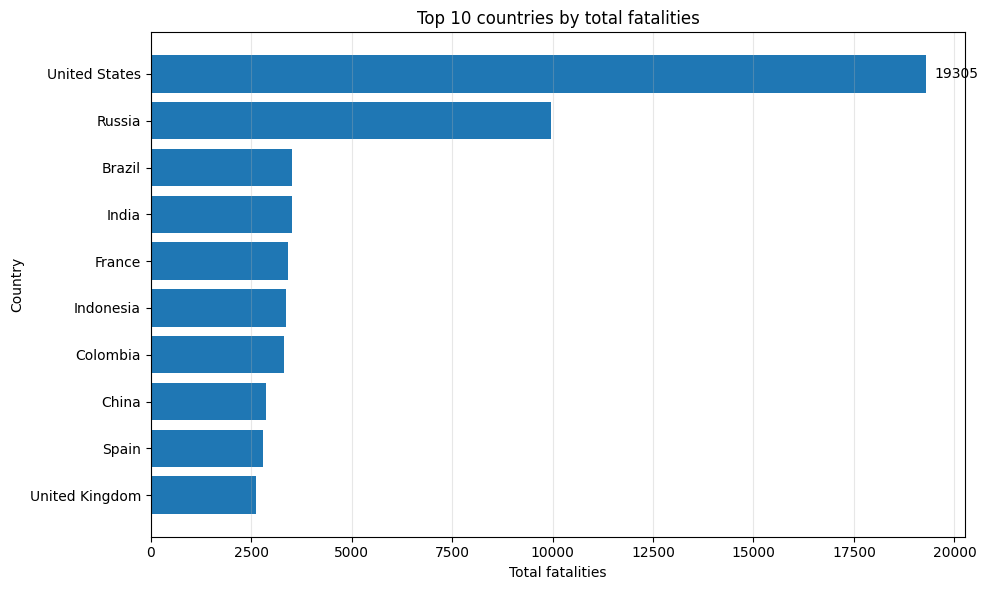

In [162]:
# Focus on the top countries by total fatalities to compare severity-based rankings
# with the earlier ranking based on accident counts.
top_10_country_fatalities = (
    country_fatalities.head(10)
    .sort_values("fatalities_clean", ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10_country_fatalities["country_clean"],
    top_10_country_fatalities["fatalities_clean"]
)

max_idx = top_10_country_fatalities["fatalities_clean"].values.argmax()
max_bar = bars[max_idx]
max_value = top_10_country_fatalities["fatalities_clean"].values[max_idx]

plt.text(
    max_value + 200,
    max_bar.get_y() + max_bar.get_height() / 2,
    str(max_value),
    va="center"
)

plt.title("Top 10 countries by total fatalities")
plt.xlabel("Total fatalities")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Supporting comparison — interpretation**

The countries with the highest number of fatalities are not perfectly identical to those with the highest number of recorded accidents.

This confirms that **accident frequency** and **accident severity** are related but distinct dimensions of aviation disasters.

#### Interpretation note
A country may appear prominently in the ranking because:

- many accidents were recorded there  
- a smaller number of especially deadly accidents occurred there  
- both frequency and severity were high  

For this reason, the comparison between **accident counts** and **total fatalities** adds useful nuance to the geographical analysis and helps avoid overly simple conclusions based on only one metric.


## Insight 2 — Do accidents happen more frequently on specific days of the week?

This insight examines whether recorded aviation accidents are distributed evenly across the **days of the week** or whether some weekdays appear more frequently than others in the dataset.

The goal is not to estimate operational risk directly, but to assess whether the temporal distribution of recorded events shows any visible imbalance.

#### Interpretation note
This analysis is based only on records with a **complete valid date**, since weekday information cannot be derived from partial or unknown dates.

As in the rest of the notebook, the results should be interpreted as **descriptive patterns in the available data**, not as direct evidence about the true probability of an accident on a given day.


In [163]:
# Use only records with a known weekday, because missing dates would distort the day-of-week distribution and the related percentages.
weekday_valid = df["weekday"].dropna().copy()

# Reindex to a fixed weekday order so the result follows calendar logic rather than frequency order.
weekday_counts = (
    weekday_valid
    .value_counts()
    .reindex(WEEKDAY_ORDER)
)

weekday_total = len(weekday_valid)
weekday_percentages = weekday_counts / weekday_total * 100

pd.DataFrame({
    "accidents": weekday_counts,
    "percentage": weekday_percentages.round(2)
})

,accidents,percentage
weekday,,
Monday,3310,14.20
Tuesday,3443,14.77
Wednesday,3491,14.98
Thursday,3513,15.08
Friday,3609,15.49
Saturday,3184,13.66
Sunday,2753,11.81


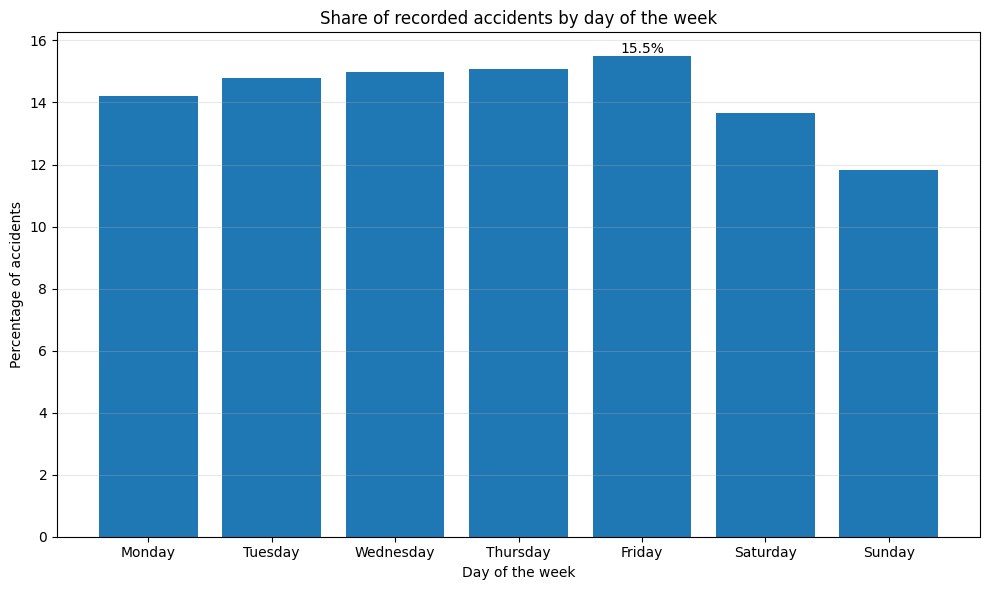

In [164]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    weekday_percentages.index,
    weekday_percentages.values
)

max_idx = weekday_percentages.values.argmax()
max_bar = bars[max_idx]
max_value = weekday_percentages.values[max_idx]

plt.text(
    max_bar.get_x() + max_bar.get_width() / 2,
    max_value + 0.1,
    f"{max_value:.1f}%",
    ha="center"
)

plt.title("Share of recorded accidents by day of the week")
plt.xlabel("Day of the week")
plt.ylabel("Percentage of accidents")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Weekday distribution — interpretation**

The chart shows a generally balanced distribution of recorded accidents across weekdays, with a visible but moderate gap.

**Friday** records the highest share, while **Sunday** records the lowest.

This suggests a descriptive imbalance in the dataset, but not a large structural difference in absolute terms.

#### Interpretation note

The chart is based only on records with a **complete valid date**.

It describes how recorded accidents are distributed across weekdays, not the real probability of an accident per flight, because flight exposure data (number of flights, traffic volume) is not available.


In [165]:
# Summarize the highest and lowest weekday shares to quantify the visible gap
# in descriptive terms before testing whether the distribution differs from uniformity.
top_weekday = weekday_counts.idxmax()
top_weekday_accidents = weekday_counts.max()
top_weekday_share = round((top_weekday_accidents / weekday_total) * 100, 2)

bottom_weekday = weekday_counts.idxmin()
bottom_weekday_accidents = weekday_counts.min()
bottom_weekday_share = round((bottom_weekday_accidents / weekday_total) * 100, 2)

weekday_gap = top_weekday_accidents - bottom_weekday_accidents
weekday_gap_pct_points = round(top_weekday_share - bottom_weekday_share, 2)

print(
    f"{top_weekday} recorded the highest number of accidents: "
    f"{top_weekday_accidents} cases ({top_weekday_share}% of records with a valid weekday). "
    f"By contrast, {bottom_weekday} recorded the lowest number: "
    f"{bottom_weekday_accidents} cases ({bottom_weekday_share}%), "
    f"for a gap of {weekday_gap} accidents ({weekday_gap_pct_points} percentage points)."
)

Friday recorded the highest number of accidents: 3609 cases (15.49% of records with a valid weekday). By contrast, Sunday recorded the lowest number: 2753 cases (11.81%), for a gap of 856 accidents (3.68 percentage points).


#### Statistical check of weekday distribution

After the descriptive comparison, we apply a chi-square goodness-of-fit test
to verify whether the weekday accident distribution is compatible with a uniform distribution.


In [166]:
import math

# Ensure setup cell has been run (it defines np).
if "np" not in globals():
    raise NameError("Run the setup/import cell first (numpy as np is required).")

# Try SciPy first; if unavailable, use a fallback approximation.
try:
    from scipy.stats import chisquare
    SCIPY_AVAILABLE = True
except Exception as e:
    chisquare = None
    SCIPY_AVAILABLE = False
    print(f"Warning: scipy is not available ({e}). Using fallback chi-square computation.")

# Keep all weekdays explicitly; missing weekdays become 0 counts.
weekday_counts_for_test = (
    df["weekday"]
    .dropna()
    .value_counts()
    .reindex(WEEKDAY_ORDER, fill_value=0)
    .astype(int)
)

observed_weekday_counts = weekday_counts_for_test.to_numpy(dtype=float)

if observed_weekday_counts.sum() == 0:
    raise ValueError("No valid weekday records available for chi-square test.")

expected_weekday_counts = np.full(
    observed_weekday_counts.shape,
    observed_weekday_counts.sum() / observed_weekday_counts.size,
    dtype=float
)

if SCIPY_AVAILABLE:
    chi2_stat, p_value = chisquare(
        f_obs=observed_weekday_counts,
        f_exp=expected_weekday_counts
    )
    pvalue_method = "Exact (SciPy)"
else:
    # Chi-square statistic computed directly.
    chi2_stat = float(((observed_weekday_counts - expected_weekday_counts) ** 2 / expected_weekday_counts).sum())

    # Fallback p-value via Wilson-Hilferty approximation of chi-square tail.
    df_chi = observed_weekday_counts.size - 1
    if df_chi <= 0:
        raise ValueError("Chi-square degrees of freedom must be positive.")

    z = (
        (chi2_stat / df_chi) ** (1 / 3)
        - (1 - 2 / (9 * df_chi))
    ) / math.sqrt(2 / (9 * df_chi))

    p_value = 0.5 * math.erfc(z / math.sqrt(2))  # upper tail
    p_value = float(min(max(p_value, 0.0), 1.0))
    pvalue_method = "Approximate (Wilson-Hilferty fallback)"

# Effect size for chi-square goodness-of-fit
n_obs = observed_weekday_counts.sum()
cohens_w = np.sqrt(chi2_stat / n_obs)

print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"P-value method: {pvalue_method}")
print(f"Cohen's w: {cohens_w:.3f}")

if cohens_w < 0.10:
    effect_label = "negligible"
elif cohens_w < 0.30:
    effect_label = "small"
elif cohens_w < 0.50:
    effect_label = "medium"
else:
    effect_label = "large"

print(f"Effect size interpretation: {effect_label}")

if p_value < 0.05:
    print(
        "The weekday distribution is statistically different from a uniform distribution. "
        f"However, Cohen's w indicates a {effect_label} effect, suggesting that the practical differences across weekdays are very small."
    )
else:
    print(
        "The weekday distribution is not statistically different from a uniform distribution. "
        "The observed differences across weekdays are consistent with random variation."
    )


Chi-square statistic: 151.59
P-value: 0.0000
P-value method: Exact (SciPy)
Cohen's w: 0.081
Effect size interpretation: negligible
The weekday distribution is statistically different from a uniform distribution. However, Cohen's w indicates a negligible effect, suggesting that the practical differences across weekdays are very small.


### Weekday distribution: beyond the p-value

The chi-square goodness-of-fit test shows that accident frequencies across weekdays are statistically different from a uniform distribution. However, because the dataset is large, statistical significance may reflect even very small deviations.

For this reason, I also computed **Cohen's *w*** to measure effect size. The result (**w = 0.081**) indicates a **negligible effect**, meaning that the practical differences across weekdays are very small.

Overall, the weekday pattern is statistically detectable, but not strong in substantive terms.

#### Weekday severity comparison

This step compares weekdays not only by accident counts, but also by total fatalities and average fatalities per accident.

In [167]:
# Compare weekdays not only by number of accidents, but also by total fatalities
# and average fatalities per accident, using records with known fatalities.
weekday_severity = (
    df.dropna(subset=["weekday", "fatalities_clean"])
    .groupby("weekday", observed=False)
    .agg(
        accidents=("weekday", "size"),
        total_fatalities=("fatalities_clean", "sum"),
        avg_fatalities_per_accident=("fatalities_clean", "mean")
    )
    .reindex(WEEKDAY_ORDER)
)

weekday_severity.round(2)

,accidents,total_fatalities,avg_fatalities_per_accident
weekday,,,
Monday,2803,17921,6.39
Tuesday,2941,21718,7.38
Wednesday,3007,20033,6.66
Thursday,3000,17599,5.87
Friday,3064,18919,6.17
Saturday,2656,17897,6.74
Sunday,2322,18594,8.01


## Insight 2 — interpretation

Accident counts vary across weekdays, and the **chi-square goodness-of-fit test** indicates that the distribution is statistically different from a uniform one.

This means that, within the available records, accidents were **not perfectly evenly distributed** across weekdays.

#### Interpretation note
The result should still be interpreted carefully:

- the observed differences remain **moderate in absolute terms**
- the dataset records **accidents**, not total flights by weekday
- statistical significance does **not** automatically imply a large practical difference

For this reason, the finding is best read as evidence of a **descriptive imbalance in the recorded data**, rather than as proof of a strong real-world gap in aviation risk between weekdays.

## Insight 3 — Can operator safety really be compared with this dataset?

This is one of the most important questions in the project, but also one of the most methodologically sensitive.

At first glance, the dataset may seem suitable for comparing operators. However, it records only **accident events** and does not include the exposure variables needed to evaluate **safety** properly.

#### Why this is a limitation

A meaningful comparison of operator safety would require information such as:

- total number of flights operated  
- passenger volume  
- fleet size  
- flight hours  

Since these variables are not available here, the dataset cannot support a true ranking of the **safest** or **most dangerous** operators.

#### What this section can show

This section can still provide useful descriptive evidence by comparing:

- how frequently operators appear in the accident records  
- how many fatalities are associated with those records  
- how historical accident profiles differ across operators with sufficient representation in the dataset  

Therefore, this analysis does **not** identify the safest operators in an absolute sense. Instead, it compares the **historical accident profiles** of operators represented in the dataset. The results should be interpreted as descriptive evidence on recorded accidents, not as a definitive ranking of operational safety.

In [168]:
# Exclude missing or generic operator labels, because they do not identify a specific operator
# and would make operator-level comparisons less meaningful.
invalid_operator_labels = {"unknown", "private", "privatè"}

operator_df = df.loc[
    df["operator_clean"].notna()
    & df["operator_clean"].str.strip().ne("")
    & ~df["operator_clean"].str.strip().str.lower().isin(invalid_operator_labels)
].copy()

# Mark military operators separately so later comparisons do not mix military
# and non-military records without distinction.
operator_df["is_military_operator"] = operator_df["record_scope"].eq("Military")

# Build an operator-level summary that combines frequency, fatalities,
# and data completeness, so later comparisons are not based only on accident counts.
operator_summary = (
    operator_df
    .groupby("operator_clean", as_index=False)
    .agg(
        accidents=("operator_clean", "size"),
        is_military_operator=("is_military_operator", "max"),
        records_with_known_fatalities=("fatalities_clean", lambda x: x.notna().sum()),
        total_fatalities=("fatalities_clean", lambda x: x.sum(min_count=1)),
        avg_fatalities_per_known_accident=("fatalities_clean", "mean"),
        fatal_accidents=("fatalities_clean", lambda x: (x > 0).sum())
    )
)

operator_summary["known_fatalities_share"] = (
    operator_summary["records_with_known_fatalities"] / operator_summary["accidents"]
)

operator_summary["fatal_accident_rate_known_only"] = (
    operator_summary["fatal_accidents"] / operator_summary["records_with_known_fatalities"]
)

operator_summary.head(15).round(2)

,operator_clean,accidents,is_military_operator,records_with_known_fatalities,total_fatalities,avg_fatalities_per_known_accident,fatal_accidents,known_fatalities_share,fatal_accident_rate_known_only
0,", op.for GoJump",1,False,1,1,1.0,1,1.0,1.0
1,", op.for Tlaxcala State Government",1,False,1,2,2.0,1,1.0,1.0
2,", op.for UN",1,False,1,0,0.0,0,1.0,0.0
3,09 Charlie,1,False,0,<NA>,<NA>,0,0.0,NaN
4,1982-047 LLC,1,False,1,0,0.0,0,1.0,0.0
5,2M Leasing,1,False,1,0,0.0,0,1.0,0.0
6,2nd Arkhangelsk United Aviation Division,3,False,3,0,0.0,0,1.0,0.0
7,2nd Sverdlovsk Aviation Enterprise,3,False,3,0,0.0,0,1.0,0.0
8,40-Mile Air,1,False,1,0,0.0,0,1.0,0.0
9,748 Air Services,5,False,5,1,0.2,1,1.0,0.2


In [169]:
# Focus on larger non-military operators with more complete fatalities data,
# so the comparison is less affected by small samples and unstable ratios.
operator_summary_major = (
    operator_summary[
        (operator_summary["accidents"] >= 20) &
        (operator_summary["known_fatalities_share"] >= 0.80) &
        (~operator_summary["is_military_operator"])
    ]
    .sort_values(
        ["fatal_accident_rate_known_only", "avg_fatalities_per_known_accident", "accidents"],
        ascending=[True, True, False]
    )
)

print(
    "Recorded-accident profile of major non-military operators "
    "(min. 20 accidents and at least 80% known fatalities). "
    "This is a descriptive comparison within the dataset, not a true safety ranking."
)

display(
    operator_summary_major.head(10).style.format({
        "avg_fatalities_per_known_accident": "{:.2f}",
        "known_fatalities_share": "{:.2%}",
        "fatal_accident_rate_known_only": "{:.2%}"
    })
)

Recorded-accident profile of major non-military operators (min. 20 accidents and at least 80% known fatalities). This is a descriptive comparison within the dataset, not a true safety ranking.


,operator_clean,accidents,is_military_operator,records_with_known_fatalities,total_fatalities,avg_fatalities_per_known_accident,fatal_accidents,known_fatalities_share,fatal_accident_rate_known_only
4980,Southwest Airlines,26,False,26,2,0.08,2,100.00%,7.69%
1949,Delta Air Lines,81,False,81,309,3.81,12,100.00%,14.81%
4556,SAS,32,False,31,230,7.42,5,96.88%,16.13%
3470,MEA,38,False,37,238,6.43,6,97.37%,16.22%
3801,National Airlines,42,False,41,126,3.07,7,97.62%,17.07%
1801,Continental Air Lines,36,False,35,86,2.46,6,97.22%,17.14%
4685,Saudi Arabian,36,False,34,645,18.97,7,94.44%,20.59%
487,Air Canada,29,False,29,139,4.79,6,100.00%,20.69%
459,Air Algérie,29,False,26,188,7.23,6,89.66%,23.08%
2934,JAL,30,False,30,733,24.43,7,100.00%,23.33%


#### Top non-military operators by total fatalities

This step ranks non-military operators by total fatalities to highlight cumulative fatal impact in the dataset.

In [170]:
# Rank non-military operators by total fatalities to see which ones are linked to the highest cumulative loss of life in the dataset.
# This shows overall historical impact, not how severe each accident was on average.
fatalities_by_operator_non_military = (
    operator_summary.loc[
        ~operator_summary["is_military_operator"],
        ["operator_clean", "total_fatalities"]
    ]
    .dropna(subset=["total_fatalities"])
    .sort_values("total_fatalities", ascending=False)
)

fatalities_by_operator_non_military.head(10)

,operator_clean,total_fatalities
895,American Airlines,3164
5649,United Airlines,2071
550,Air France,1676
4095,Pan American World Airways,1663
5240,TWA,1081
5221,THY,902
1661,China Airlines,855
2812,Indian Airlines,849
4049,PIA,849
303,"Aeroflot, Ukraine",807


#### Visualization of top non-military operators by total fatalities


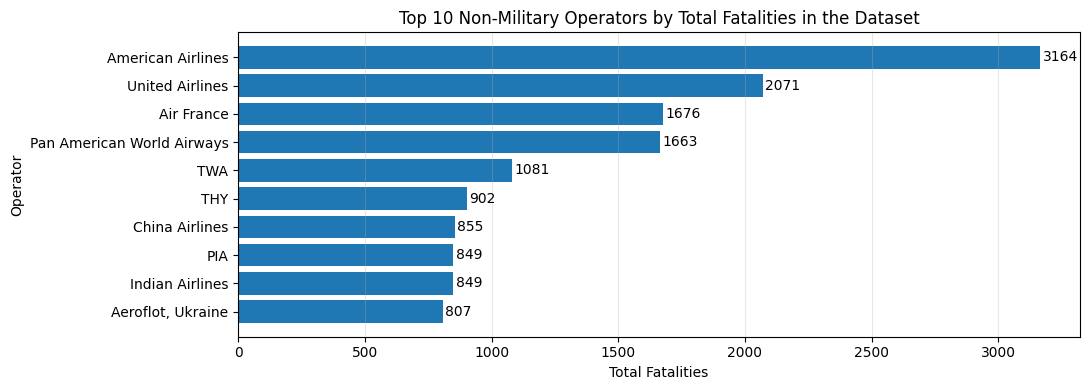

In [171]:
top10_fatal_operators_non_military = (
    fatalities_by_operator_non_military
    .head(10)
    .sort_values("total_fatalities", ascending=True)
)

plt.figure(figsize=(11, 4))

bars = plt.barh(
    top10_fatal_operators_non_military["operator_clean"],
    top10_fatal_operators_non_military["total_fatalities"]
)

plt.title("Top 10 Non-Military Operators by Total Fatalities in the Dataset")
plt.xlabel("Total Fatalities")
plt.ylabel("Operator")
plt.grid(axis="x", alpha=0.3)

for bar, value in zip(bars, top10_fatal_operators_non_military["total_fatalities"]):
    plt.text(
        value + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center"
    )

plt.tight_layout()
plt.show()

**Insight 3 — interpretation**

Among **non-military operators**, airlines such as **American Airlines**, **United Airlines**, **Air France**, and **Pan American World Airways** are associated with the highest total number of fatalities in the dataset.

This indicates that these operators appear prominently in the historical accident record and are linked to a large cumulative human toll.

#### Methodological note
This should **not** be interpreted as evidence that these were the least safe operators.

The result reflects only the fatality burden observed in the accident dataset and does not account for key exposure variables such as:

- total flights operated  
- passenger volume  
- fleet size  
- flight hours  

For this reason, the chart is best read as a comparison of **historical fatal accident impact among recorded operators**, not as a definitive safety ranking.

## Insight 4 — Which aircraft types were associated with the highest number of fatalities?

This section examines the relationship between **aircraft type** and the total number of **recorded fatalities**.

The goal is to identify which aircraft labels appear most prominently in the dataset when fatalities are aggregated, while also addressing an important limitation: the `type` field is highly detailed and often fragmented across variants of the same aircraft family.

#### Methodological note
A direct ranking based only on raw aircraft labels can be difficult to interpret, because:

- very similar aircraft may appear under slightly different names  
- broad families and specific variants may coexist in the same field  
- some labels may be associated with only a small number of recorded accidents  

For this reason, the analysis combines **raw-type rankings** with more interpretable **family-level groupings** and threshold-based comparisons.

In [172]:
# We inspect the raw aircraft type labels before any grouping because this column is highly fragmented
# (e.g. spelling variants, model variants, military/civil naming differences).
type_counts = df["type"].astype("string").value_counts(dropna=False)

print("Unique raw aircraft types:", df["type"].astype("string").nunique(dropna=False))

type_counts.head(20).rename_axis("aircraft_type").reset_index(name="accident_count")

Unique raw aircraft types: 3201


,aircraft_type,accident_count
0,Douglas C-47A (DC-3),1916
1,Douglas C-47 (DC-3),668
2,Douglas C-47B (DC-3),592
3,Curtiss C-46A,564
4,Antonov An-2R,391
5,Junkers Ju-52/3m,375
6,Curtiss C-46D,344
7,Douglas Dakota III (DC-3),262
8,DHC-6 Twin Otter 300,258
9,Cessna 208B Grand Caravan,247


### Note on the `type` variable

The `type` field is highly granular and heterogeneous: some labels refer to broad aircraft families, while others identify very specific variants.

For this reason, the analysis in this section should be interpreted with caution.

#### Interpretation note
Rankings based on raw aircraft labels can be informative, but they may also reflect:

- naming fragmentation across very similar models  
- the coexistence of broad families and highly specific variants  
- differences in labeling rather than truly distinct aircraft categories  

As a result, aircraft-type comparisons are more useful when read as **descriptive patterns in the recorded data** rather than as perfectly standardized technical rankings.

In [173]:
# Keep only records with a reported aircraft type because missing labels
# cannot support a meaningful type-level comparison.
type_fatalities_df = df[df["type"].notna()].copy()

# Cleaning is intentionally light: it removes only superficial formatting
# differences without merging distinct aircraft variants.
type_fatalities_df["type_clean"] = (
    type_fatalities_df["type"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Build the initial summary before filtering, so the raw distribution
# can be compared with the more robust ranking.
type_summary = build_fatality_summary(type_fatalities_df, "type_clean")

# Keep all cleaned labels with known total fatalities.
# This is the base table for ranking and share calculations.
type_summary_main = (
    type_summary
    .dropna(subset=["total_fatalities"])
    .sort_values("total_fatalities", ascending=False)
    .copy()
)

total_fatalities_all_types = type_summary_main["total_fatalities"].sum()

type_summary_main["fatalities_share_of_total"] = (
    type_summary_main["total_fatalities"] / total_fatalities_all_types
)

# Apply filters to reduce unstable results from labels with too few
# accidents or too much missing fatality information.
type_summary_robust = (
    type_summary_main[
        (type_summary_main["accidents"] >= 5) &
        (type_summary_main["known_fatalities_share"] >= 0.80)
    ]
    .sort_values(
        [
            "total_fatalities",
            "avg_fatalities_per_known_accident",
            "fatal_accident_rate_known_only"
        ],
        ascending=[False, False, False]
    )
)

print("Top aircraft types by total fatalities (robust view: min. 5 accidents and at least 80% known fatalities):")
display(
    type_summary_robust.head(10).style.format({
        "avg_fatalities_per_known_accident": "{:.2f}",
        "known_fatalities_share": "{:.2%}",
        "fatal_accident_rate_known_only": "{:.2%}",
        "fatalities_share_of_total": "{:.2%}"
    })
)

Top aircraft types by total fatalities (robust view: min. 5 accidents and at least 80% known fatalities):


,accidents,records_with_known_fatalities,total_fatalities,avg_fatalities_per_known_accident,fatal_accidents,known_fatalities_share,fatal_accident_rate_known_only,fatalities_share_of_total
type_clean,,,,,,,,
Tupolev Tu-154M,34,34,1600,47.06,17,100.00%,50.00%,1.21%
DC-9-32,67,67,1441,21.51,25,100.00%,37.31%,1.09%
Ilyushin Il-18V,53,50,1356,27.12,29,94.34%,58.00%,1.02%
Lockheed C-130H Hercules,73,68,1271,18.69,51,93.15%,75.00%,0.96%
Antonov An-26,137,120,1246,10.38,71,87.59%,59.17%,0.94%
Douglas DC-6B,64,63,1074,17.05,36,98.44%,57.14%,0.81%
DHC-6 Twin Otter 300,258,252,1056,4.19,125,97.67%,49.60%,0.80%
Tupolev Tu-134A,41,41,878,21.41,20,100.00%,48.78%,0.66%
Antonov An-24RV,70,66,846,12.82,34,94.29%,51.52%,0.64%


**Family-level grouping — interpretation**

The family-level grouping provides a more interpretable complement to the raw-type rankings.

By combining closely related aircraft labels, it reduces part of the fragmentation of the `type` field and makes broader historical patterns easier to identify.

#### Methodological note
This grouped view remains an **approximation**, not a perfectly standardized aircraft taxonomy.

Even so, it is often more meaningful than a ranking based only on the original raw labels, because it helps shift the focus from naming variation to broader aircraft-family patterns in the recorded data.

In [174]:
# Keep the ten aircraft types with the highest total fatalities after robustness filtering.
# This avoids rankings that are overly influenced by rare labels or sparse fatality data.
top_10_types_main = (
    type_summary_robust["total_fatalities"]
    .head(10)
    .sort_values(ascending=True)
    .astype(int)
)

display(
    top_10_types_main
    .rename_axis("type_clean")
    .reset_index(name="total_fatalities")
)

,type_clean,total_fatalities
0,Douglas DC-4,838
1,Antonov An-24RV,846
2,Tupolev Tu-134A,878
3,DHC-6 Twin Otter 300,1056
4,Douglas DC-6B,1074
5,Antonov An-26,1246
6,Lockheed C-130H Hercules,1271
7,Ilyushin Il-18V,1356
8,DC-9-32,1441
9,Tupolev Tu-154M,1600


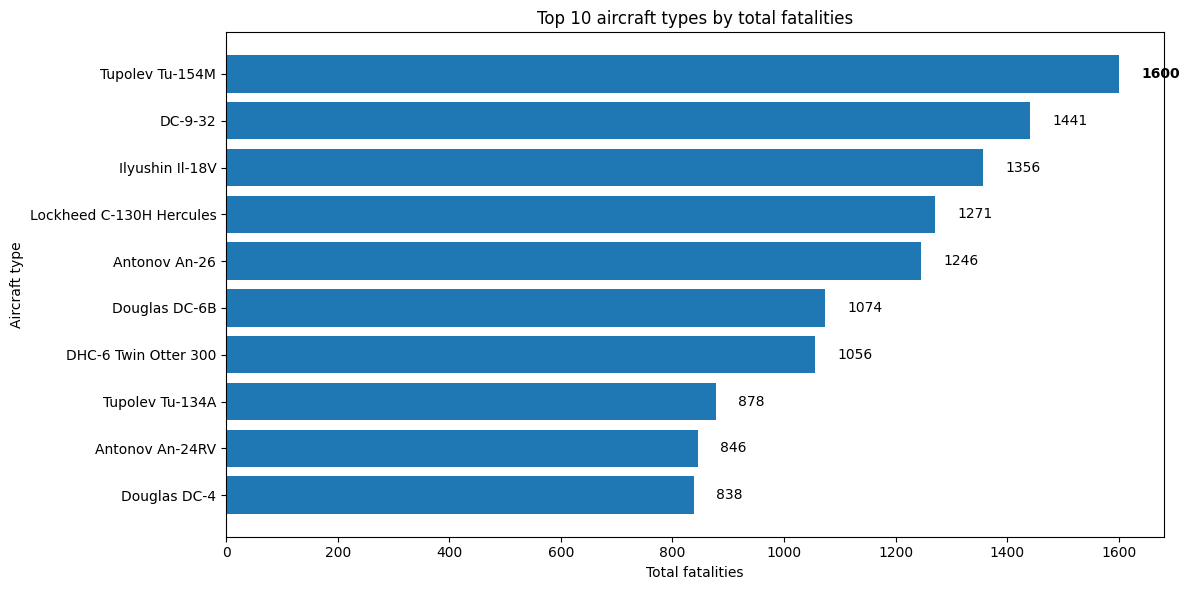

In [175]:
plt.figure(figsize=(12, 6))

bars = plt.barh(top_10_types_main.index, top_10_types_main.values)

max_idx = top_10_types_main.values.argmax()
max_value = top_10_types_main.values[max_idx]

for i, value in enumerate(top_10_types_main.values):
    plt.text(
        value + 40,
        i,
        f"{int(value)}",
        va="center",
        fontsize=10,
        fontweight="bold" if i == max_idx else "normal"
    )

plt.title("Top 10 aircraft types by total fatalities")
plt.xlabel("Total fatalities")
plt.ylabel("Aircraft type")
plt.tight_layout()
plt.show()

**Threshold-based ranking — interpretation**

Applying a minimum threshold of **5 recorded accidents** makes the ranking easier to interpret by reducing the influence of aircraft labels associated with only a handful of observations.

This helps highlight raw aircraft types that combine:

- a high cumulative death toll  
- a more substantial presence in the dataset  

#### Methodological note
Without a minimum threshold, rankings can be dominated by aircraft labels linked to very few events, which may appear prominent only because of one exceptionally severe accident.

The threshold-based view therefore provides a more balanced complement to the raw ranking and supports a more cautious interpretation of aircraft-type severity.

### Interpreting aircraft types more carefully

Aircraft labels in the raw dataset are often fragmented across very similar variants of the same model family (for example, different versions of the **Douglas DC-3 / C-47** family).

For this reason, the notebook presents both:
- the original ranking based on **raw aircraft labels**
- a broader **family-based grouping**

#### Interpretation note
The goal is not to claim a perfect aircraft classification, but to reduce the distortion caused by naming fragmentation and make the results more meaningful.

This approach helps the analysis move from highly specific labels toward broader historical patterns, while still acknowledging that the grouping remains an analytical approximation rather than a definitive technical taxonomy.

In [176]:
# Group similar aircraft labels into broader families to reduce name fragmentation.
aircraft_family_patterns = {
    "Douglas DC Series": r"\b(?:DC[- ]?(?:3|4|6|7|8|10)|C[- ]?47)\b|Douglas (?:DC[- ]?(?:3|4|6|7|8|10)|C[- ]?47)|Skytrain|Dakota",
    "Boeing 727": r"\b727\b|Boeing 727",
    "Boeing 737": r"\b737\b|Boeing 737",
    "Boeing 747": r"\b747\b|Boeing 747",
    "Boeing 757": r"\b757\b|Boeing 757",
    "Boeing 767": r"\b767\b|Boeing 767",
    "Boeing 777": r"\b777\b|Boeing 777",
    "Airbus A300/A310": r"\bA300\b|\bA310\b|Airbus A300|Airbus A310",
    "Airbus A320 Family": r"\bA318\b|\bA319\b|\bA320\b|\bA321\b|Airbus A32",
    "Airbus A330/A340": r"\bA330\b|\bA340\b|Airbus A330|Airbus A340",
    "Lockheed L-188 Electra": r"Electra|L-188",
    "Lockheed Constellation": r"Constellation|L-049|L-1049|Super Constellation",
    "Lockheed C-130 Hercules": r"C-130|Hercules",
    "Antonov An-24/26/32": r"An[- ]?(?:24|26|32)\b|Antonov An[- ]?(?:24|26|32)",
    "Antonov An-2": r"An[- ]?2\b|Antonov An[- ]?2",
    "Ilyushin Il-18/62/76": r"Il[- ]?(?:18|62|76)\b|Ilyushin Il[- ]?(?:18|62|76)",
    "Tupolev Tu-104/134/154": r"Tu[- ]?(?:104|134|154)\b|Tupolev Tu[- ]?(?:104|134|154)",
    "de Havilland DHC-6 Twin Otter": r"Twin Otter|DHC-6",
    "de Havilland Comet": r"\bComet\b|de Havilland Comet",
    "Fokker F27/F28/F50/F100": r"F27|F28|F50|F100|Fokker",
    "McDonnell Douglas DC-9/MD-80/90 Family": r"DC-9|MD-8[0-9]|MD-90",
    "ATR 42/72": r"\bATR[- ]?(?:42|72)\b|ATR 42|ATR 72",
    "Dash 8 / Q Series": r"Dash[- ]?8|\bQ200\b|\bQ300\b|\bQ400\b",
    "Cessna 208 Caravan": r"Cessna 208|Caravan",
    "Curtiss C-46 Commando": r"C-46|Curtiss C-46|Commando",
    "CASA / CN-235": r"CN[- ]?235|CASA 235|CASA / IPTN CN-235",
}

In [177]:
# Assign a family label when a cleaned aircraft type matches one of the predefined patterns.
# Labels that do not match any family remain classified as "Other / unclassified".
type_fatalities_df["aircraft_family"] = "Other / Unclassified"

for family, pattern in aircraft_family_patterns.items():
    unclassified_mask = type_fatalities_df["aircraft_family"].eq("Other / Unclassified")
    match_mask = type_fatalities_df["type_clean"].str.contains(pattern, case=False, na=False, regex=True)
    type_fatalities_df.loc[unclassified_mask & match_mask, "aircraft_family"] = family

In [178]:
# Summarize fatalities at the aircraft-family level to reduce the fragmentation of raw type labels.
# Exclude the residual group so the comparison focuses on the predefined families.
family_summary = build_fatality_summary(type_fatalities_df, "aircraft_family")

family_summary_main = (
    family_summary
    .dropna(subset=["total_fatalities"])
    .loc[lambda x: x.index != "Other / Unclassified"]
    .sort_values("total_fatalities", ascending=False)
)

family_summary_main.style.format({
    "avg_fatalities_per_known_accident": "{:.2f}",
    "known_fatalities_share": "{:.2%}",
    "fatal_accident_rate_known_only": "{:.2%}"
})

,accidents,records_with_known_fatalities,total_fatalities,avg_fatalities_per_known_accident,fatal_accidents,known_fatalities_share,fatal_accident_rate_known_only
aircraft_family,,,,,,,
Douglas DC Series,5615,3792,26476,6.98,2229,67.53%,58.78%
Boeing 737,534,532,5853,11.00,114,99.63%,21.43%
Tupolev Tu-104/134/154,263,259,5714,22.06,106,98.48%,40.93%
Ilyushin Il-18/62/76,242,228,4735,20.77,114,94.21%,50.00%
Antonov An-24/26/32,501,453,4702,10.38,233,90.42%,51.43%
Boeing 727,353,353,4253,12.05,75,100.00%,21.25%
Lockheed C-130 Hercules,416,385,3867,10.04,238,92.55%,61.82%
McDonnell Douglas DC-9/MD-80/90 Family,285,285,3849,13.51,75,100.00%,26.32%
Boeing 747,174,174,3845,22.10,37,100.00%,21.26%


#### Robust family-level view

In this step, we apply minimum filters at family level as well
(accident count and fatalities completeness), so the final chart
is based on more stable comparisons and less influenced by rare labels.


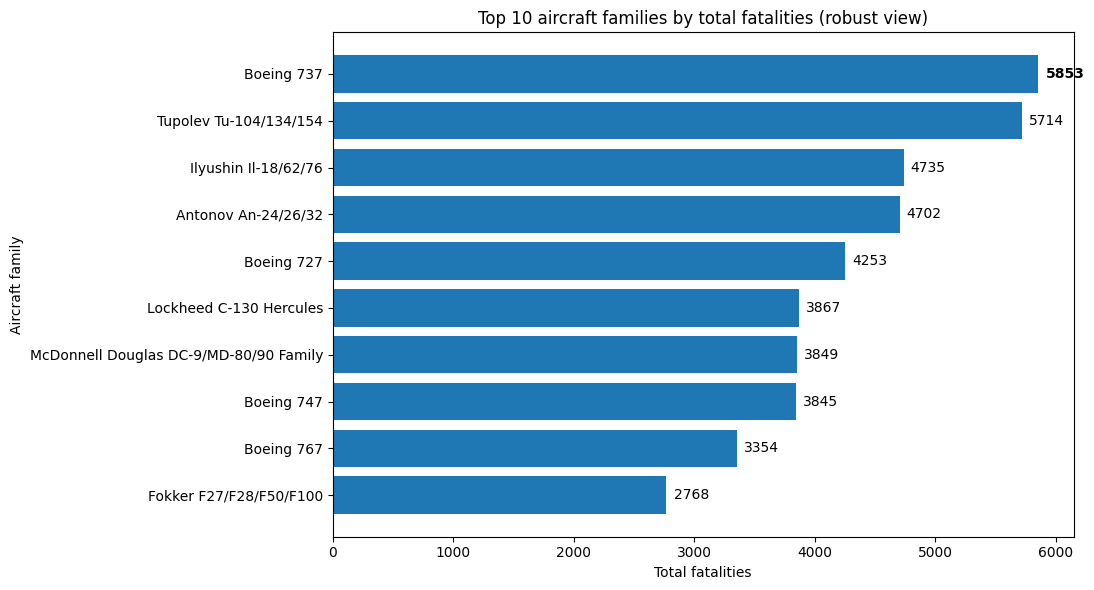

In [179]:
# Apply the same robustness filters used earlier so family-level comparisons remain more stable.
# Keep the top aircraft families by total fatalities for the family-level chart.
family_summary_robust = (
    family_summary_main.loc[
        (family_summary_main["accidents"] >= 5) &
        (family_summary_main["known_fatalities_share"] >= 0.80)
    ]
    .copy()
)

# Keep the leading aircraft families by cumulative fatalities for the robust family-level chart.
top10_families_by_fatalities = (
    family_summary_robust
    .nlargest(10, "total_fatalities")
    .sort_values("total_fatalities", ascending=True)
    .reset_index()
)

top10_families_by_fatalities["total_fatalities"] = (
    pd.to_numeric(top10_families_by_fatalities["total_fatalities"], errors="coerce")
)

top10_families_by_fatalities = top10_families_by_fatalities.dropna(
    subset=["total_fatalities", "aircraft_family"]
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top10_families_by_fatalities["aircraft_family"],
    top10_families_by_fatalities["total_fatalities"]
)

max_value = top10_families_by_fatalities["total_fatalities"].max()

for i, value in enumerate(top10_families_by_fatalities["total_fatalities"]):
    plt.text(
        value + max_value * 0.01,
        i,
        f"{int(value)}",
        va="center",
        fontsize=10,
        fontweight="bold" if value == max_value else "normal"
    )

plt.title("Top 10 aircraft families by total fatalities (robust view)")
plt.xlabel("Total fatalities")
plt.ylabel("Aircraft family")
plt.tight_layout()
plt.show()

### Robust family-level view — interpretation

In the robust family-level chart, fatalities are concentrated in a limited set of aircraft families, with Boeing 737 and Tupolev Tu-104/134/154 at the top.

Compared with raw-label rankings, the family grouping reduces naming fragmentation and makes broader historical patterns easier to interpret.

#### Interpretation note
This remains an analytical approximation, not a fully standardized aircraft taxonomy.

The grouping is manually defined, and results are constrained to families with:

- at least 5 recorded accidents
- at least 80% known fatalities

For this reason, the chart should be read as a **descriptive pattern in recorded data**, not as a definitive technical ranking.


## Insight 5 — How did accidents evolve after September 11?

This insight compares recorded aviation accidents before and after 9/11 using two symmetric 10-year windows and a yearly trend view.

The goal is to assess whether the post-2001 period shows a consistent shift in accident frequency and fatality burden within the available records.

#### Interpretation note
The analysis uses only records with a valid full date, because the 9/11 split requires precise temporal attribution.

The comparison is descriptive and should not be interpreted as a causal estimate.


In [180]:
# Restrict the comparison to records with a valid full date, because the 9/11 split
# requires precise temporal attribution.
dated_accidents = df[df["date_clean"].notna()].copy()

In [181]:
# Define the 9/11 threshold date
sept_11 = pd.Timestamp("2001-09-11")

In [182]:
# Create two comparable 10-year periods based on the full date:
# 1991-09-11 to 2001-09-10 and 2001-09-12 to 2011-09-11
before_911_period = dated_accidents[
    (dated_accidents["date_clean"] >= pd.Timestamp("1991-09-11")) &
    (dated_accidents["date_clean"] < pd.Timestamp("2001-09-11"))
]

after_911_period = dated_accidents[
    (dated_accidents["date_clean"] > pd.Timestamp("2001-09-11")) &
    (dated_accidents["date_clean"] <= pd.Timestamp("2011-09-11"))
]

In [183]:
# Compare two symmetric 10-year windows around 9/11 to reduce the effect of
# uneven period lengths and make the before/after summary more interpretable.
comparison_911 = pd.DataFrame(
    {
        "accidents": [
            len(before_911_period),
            len(after_911_period)
        ],
        "avg_accidents_per_year": [
            round(len(before_911_period) / 10, 2),
            round(len(after_911_period) / 10, 2)
        ],
        "known_fatalities_records": [
            before_911_period["fatalities_clean"].notna().sum(),
            after_911_period["fatalities_clean"].notna().sum()
        ],
        "known_fatalities_share": [
            round(before_911_period["fatalities_clean"].notna().mean(), 3),
            round(after_911_period["fatalities_clean"].notna().mean(), 3)
        ],
        "fatal_accidents": [
            (before_911_period["fatalities_clean"] > 0).sum(),
            (after_911_period["fatalities_clean"] > 0).sum()
        ],
        "total_fatalities": [
            before_911_period["fatalities_clean"].sum(min_count=1),
            after_911_period["fatalities_clean"].sum(min_count=1)
        ],
        "avg_fatalities_per_year": [
            round(before_911_period["fatalities_clean"].sum(min_count=1) / 10, 2),
            round(after_911_period["fatalities_clean"].sum(min_count=1) / 10, 2)
        ],
        "avg_fatalities_per_known_accident": [
            round(before_911_period["fatalities_clean"].mean(), 2),
            round(after_911_period["fatalities_clean"].mean(), 2)
        ],
# Compute the share of fatal accidents only among records with known fatalities,
# so that missing values do not distort the rate.
        "fatal_accident_rate_known_only": [
            round((before_911_period["fatalities_clean"] > 0).sum() / before_911_period["fatalities_clean"].notna().sum(), 3),
            round((after_911_period["fatalities_clean"] > 0).sum() / after_911_period["fatalities_clean"].notna().sum(), 3)
        ]
    },
    index=[
        "Before 9/11\n(1991-09-11 to 2001-09-10)",
        "After 9/11\n(2001-09-12 to 2011-09-11)"
    ]
)

comparison_911.loc["% change\n(after vs before)"] = [
    round((comparison_911.iloc[1]["accidents"] - comparison_911.iloc[0]["accidents"]) / comparison_911.iloc[0]["accidents"] * 100, 2),
    round((comparison_911.iloc[1]["avg_accidents_per_year"] - comparison_911.iloc[0]["avg_accidents_per_year"]) / comparison_911.iloc[0]["avg_accidents_per_year"] * 100, 2),
    round((comparison_911.iloc[1]["known_fatalities_records"] - comparison_911.iloc[0]["known_fatalities_records"]) / comparison_911.iloc[0]["known_fatalities_records"] * 100, 2),
    round((comparison_911.iloc[1]["known_fatalities_share"] - comparison_911.iloc[0]["known_fatalities_share"]) / comparison_911.iloc[0]["known_fatalities_share"] * 100, 2),
    round((comparison_911.iloc[1]["fatal_accidents"] - comparison_911.iloc[0]["fatal_accidents"]) / comparison_911.iloc[0]["fatal_accidents"] * 100, 2),
    round((comparison_911.iloc[1]["total_fatalities"] - comparison_911.iloc[0]["total_fatalities"]) / comparison_911.iloc[0]["total_fatalities"] * 100, 2),
    round((comparison_911.iloc[1]["avg_fatalities_per_year"] - comparison_911.iloc[0]["avg_fatalities_per_year"]) / comparison_911.iloc[0]["avg_fatalities_per_year"] * 100, 2),
    round((comparison_911.iloc[1]["avg_fatalities_per_known_accident"] - comparison_911.iloc[0]["avg_fatalities_per_known_accident"]) / comparison_911.iloc[0]["avg_fatalities_per_known_accident"] * 100, 2),
    round((comparison_911.iloc[1]["fatal_accident_rate_known_only"] - comparison_911.iloc[0]["fatal_accident_rate_known_only"]) / comparison_911.iloc[0]["fatal_accident_rate_known_only"] * 100, 2)
]

avg_accidents_911 = comparison_911.loc[
    [
        "Before 9/11\n(1991-09-11 to 2001-09-10)",
        "After 9/11\n(2001-09-12 to 2011-09-11)"
    ],
    "avg_accidents_per_year"
]

comparison_911

,accidents,avg_accidents_per_year,known_fatalities_records,known_fatalities_share,fatal_accidents,total_fatalities,avg_fatalities_per_year,avg_fatalities_per_known_accident,fatal_accident_rate_known_only
Before 9/11\n(1991-09-11 to 2001-09-10),2421.00,242.10,2338.0,0.966,896.00,16193.00,1619.30,6.93,0.383
After 9/11\n(2001-09-12 to 2011-09-11),2132.00,213.20,2123.0,0.996,637.00,10666.00,1066.60,5.02,0.300
% change\n(after vs before),-11.94,-11.94,-9.2,3.110,-28.91,-34.13,-34.13,-27.56,-21.670


#### Yearly trend around 2001

This time-series view shows yearly accident counts from 1990 to 2022, with a rolling average to smooth short-term fluctuations.
It is used to visually contextualize the before/after 9/11 comparison and should be read as a descriptive trend, not a causal estimate.


#### Summary table for the two symmetric 10-year windows

The table below compares the pre- and post-9/11 periods across accident frequency, fatal accidents, total fatalities, and selected severity indicators.  
The last row reports the percentage change in the post-9/11 window relative to the pre-9/11 window.

,accidents,avg_accidents_per_year,known_fatalities_records,known_fatalities_share,fatal_accidents,total_fatalities,avg_fatalities_per_year,avg_fatalities_per_known_accident,fatal_accident_rate_known_only
Before 9/11\n(1991-09-11 to 2001-09-10),2421.00,242.10,2338.0,0.966,896.00,16193.00,1619.30,6.93,0.383
After 9/11\n(2001-09-12 to 2011-09-11),2132.00,213.20,2123.0,0.996,637.00,10666.00,1066.60,5.02,0.300
% change\n(after vs before),-11.94,-11.94,-9.2,3.110,-28.91,-34.13,-34.13,-27.56,-21.670


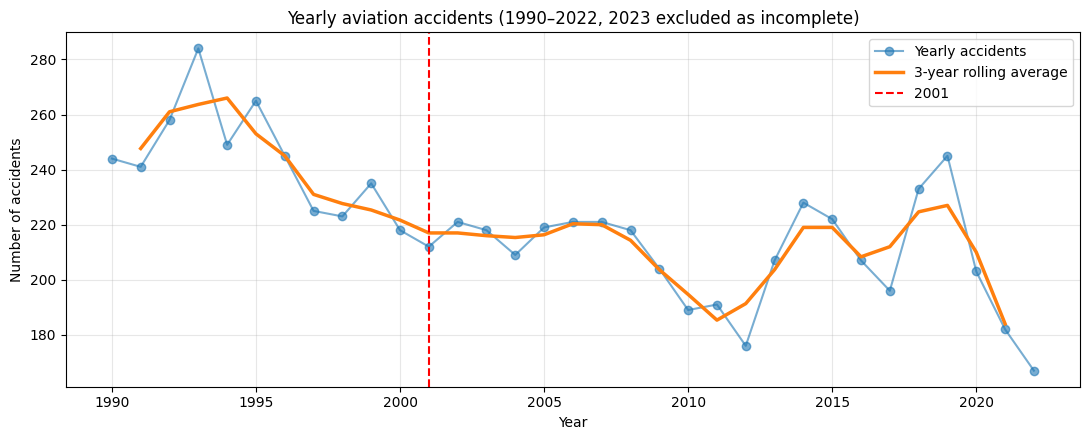

In [184]:
# Plot the yearly trend around 9/11 using only accidents with a valid full date.
# Exclude 2023 because it appears incomplete, and add a 3-year rolling average
# to smooth short-term volatility around the break.
accidents_1990_2023 = (
    dated_accidents.loc[dated_accidents["date_clean"].dt.year.between(1990, 2023)]
    .assign(year=lambda x: x["date_clean"].dt.year)
    .groupby("year")
    .size()
)

accidents_1990_2022 = accidents_1990_2023.loc[accidents_1990_2023.index <= 2022]
rolling_avg_3y = accidents_1990_2022.rolling(window=3, center=True).mean()

before_value = avg_accidents_911.iloc[0]
after_value = avg_accidents_911.iloc[1]
pct_change = ((after_value - before_value) / before_value) * 100

display(comparison_911)

plt.figure(figsize=(11, 4.5))
plt.plot(
    accidents_1990_2022.index,
    accidents_1990_2022.values,
    marker="o",
    alpha=0.6,
    label="Yearly accidents"
)
plt.plot(
    rolling_avg_3y.index,
    rolling_avg_3y.values,
    linewidth=2.5,
    label="3-year rolling average"
)
plt.axvline(2001, color="red", linestyle="--", label="2001")
plt.title("Yearly aviation accidents (1990–2022, 2023 excluded as incomplete)")
plt.xlabel("Year")
plt.ylabel("Number of accidents")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Pre-/post-9/11 comparison — interpretation**

The comparison between the two symmetric 10-year windows shows a lower accident burden in the period after September 11, 2001. In the post-9/11 decade, the dataset records fewer accidents on average per year, fewer fatal accidents, and lower total fatalities than in the decade before.

The yearly trend shown in the chart is broadly consistent with this result. After the higher levels observed in the early 1990s, accident counts generally move on a lower plateau after 2001, although the series remains irregular and still includes temporary rebounds.

Overall, the evidence suggests a downward shift in recorded accidents and fatalities in the decade following 9/11 within this dataset.

#### Interpretation note

This result should be interpreted as a descriptive comparison, not as evidence that 9/11 directly caused the decline. The dataset does not include information on total flight volume, traffic exposure, regulatory changes, technological progress, or broader structural transformations in aviation over time.

In addition, the comparison is based on recorded accidents only. For this reason, the observed reduction should be read as a pattern within the dataset rather than as a direct measure of underlying operational risk.


#### Compact before/after 9/11 comparison

After the yearly trend view, this chart directly compares
average accidents per year across the two symmetric 10-year windows.


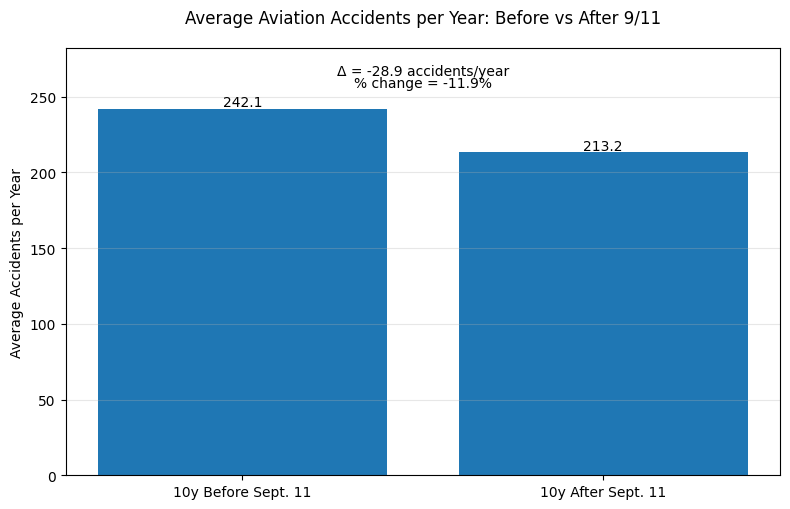

In [185]:
before_value = comparison_911.loc["Before 9/11\n(1991-09-11 to 2001-09-10)", "avg_accidents_per_year"]
after_value = comparison_911.loc["After 9/11\n(2001-09-12 to 2011-09-11)", "avg_accidents_per_year"]

# Percentage change from the pre-9/11 period to the post-9/11 period
pct_change = ((after_value - before_value) / before_value) * 100

# Absolute difference in average accidents per year
abs_change = after_value - before_value

labels = ["10y Before Sept. 11", "10y After Sept. 11"]
values = [before_value, after_value]

# Create the chart with a bit more vertical space for the annotations
plt.figure(figsize=(8, 5.2))

bars = plt.bar(labels, values)

plt.ylabel("Average Accidents per Year")
plt.title("Average Aviation Accidents per Year: Before vs After 9/11", pad=18)
plt.grid(axis="y", alpha=0.3)

# Increase the upper limit of the y-axis so the annotations are easy to read
y_max = max(values)
plt.ylim(0, y_max + 40)

# Show the exact value on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.1f}",
        ha="center"
    )

# Add the absolute change above the bars
plt.text(
    0.5,
    y_max + 22,
    f"Δ = {abs_change:.1f} accidents/year",
    ha="center",
    fontsize=10
)

# Add the percentage change below the absolute change
plt.text(
    0.5,
    y_max + 14,
    f"% change = {pct_change:.1f}%",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

### Pre-/post-9/11 comparison — interpretation

Using two comparable 10-year windows, the chart shows that the average number of recorded accidents per year is lower in the post-9/11 period than in the decade immediately before September 11, 2001.

The bar labels and top annotations make the comparison more explicit by showing both the absolute change in average accidents per year and the percentage change between the two periods. This makes the downward shift easier to read directly from the chart.

Overall, the figure suggests a lower average accident burden in the decade after 9/11 within this dataset.

**Interpretation note**

This comparison is descriptive and should not be interpreted as evidence that 9/11 directly caused the decline. The dataset does not include information on flight volume, traffic exposure, regulatory changes, or other long-term structural factors that may also have influenced accident trends over time.

In addition, the result is based on recorded accidents only. It therefore describes a pattern within the dataset rather than an adjusted measure of operational risk.
    

## Geographic distribution — interpretation

The three visualizations (choropleth map, cartogram, and bubble map) show that recorded aviation accidents are unevenly distributed across countries. A relatively small number of countries accounts for a much higher number of accidents, while most others show lower values.

The choropleth map displays absolute values through color intensity, the bubble map highlights concentration through marker size, and the cartogram emphasizes spatial concentration by resizing the area of countries.

#### Interpretation note
Both the choropleth map and the bubble map represent the absolute number of recorded accidents by country.  
The cartogram is an optional bonus visualization and is shown only if the required geospatial libraries and the necessary cartographic data are available. For readability, country areas are scaled based on `sqrt(accidents)`, while color intensity represents the actual number of recorded accidents.

In [186]:
# Build a country-level count table from cleaned country labels to support
# both the choropleth view and the bubble-map view.
country_counts_map = (
    df["country_clean"]
    .dropna()
    .value_counts()
    .rename_axis("country")
    .reset_index(name="accidents")
)

In [187]:
country_map_plot = country_counts_map.copy()

# Harmonize a few country names so they match Plotly's geographic naming conventions.
# Without these fixes, some countries may fail to render correctly on the map.
PLOTLY_COUNTRY_FIXES = {
    "Czech Republic": "Czechia",
    "North Korea": "Korea, Democratic People's Republic of",
    "South Korea": "Korea, Republic of",
    "Syrian Arab Republic": "Syria",
    "Lao PDR": "Lao People's Democratic Republic",
    "Republic of Moldova": "Moldova, Republic of",
    "United Republic of Tanzania": "Tanzania, United Republic of",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "Vietnam": "Viet Nam",
    "Bolivia": "Bolivia, Plurinational State of",
    "Brunei": "Brunei Darussalam",
    "Cabo Verde": "Cape Verde",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Democratic Republic of the Congo": "Congo, The Democratic Republic of the",
    "Republic of the Congo": "Congo",
    "Federated States of Micronesia": "Micronesia, Federated States of",
    "Türkiye": "Turkey"
}

country_map_plot["country_plot"] = (
    country_map_plot["country"]
    .replace(PLOTLY_COUNTRY_FIXES)
)

In [188]:
# Optional setup for the cartogram bonus section.
# If installation fails, the notebook continues and the bonus is skipped.

import sys
import subprocess

try:
    import cartogram  # noqa: F401
    print("cartogram is already installed.")
except ImportError:
    print("Installing cartogram for the bonus cartogram section...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cartogram"])
        import cartogram  # noqa: F401
        print("cartogram installed successfully.")
    except Exception as e:
        print(f"Warning: cartogram not available ({e}). The bonus cartogram section will be skipped.")

cartogram is already installed.


In [189]:
# Optional imports for the geographic bonus sections
try:
    import geopandas as gpd
    HAS_GEOPANDAS = True
except Exception as e:
    gpd = None
    HAS_GEOPANDAS = False
    print(f"Package 'geopandas' is not available ({e}). Geographic bonus sections may be skipped.")

try:
    import cartogram
    HAS_CARTOGRAM = True
except Exception as e:
    cartogram = None
    HAS_CARTOGRAM = False
    print(f"Package 'cartogram' is not available ({e}). The cartogram bonus section may be skipped.")

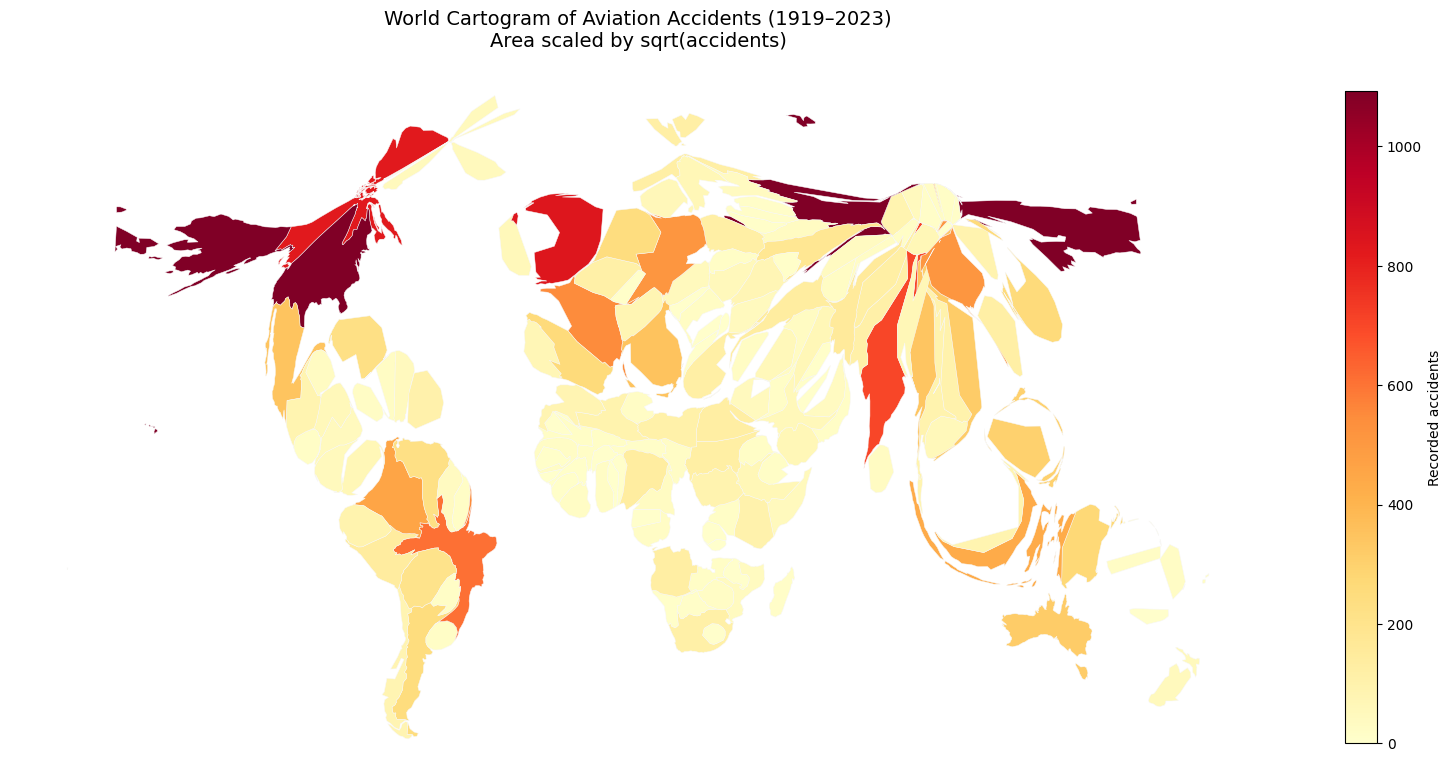

In [190]:
import warnings

# Bonus section: never block the notebook if prerequisites are missing.
if "country_counts_map" not in globals():
    warnings.warn(
        "Skipping cartogram bonus: run the cell that creates `country_counts_map` first.",
        RuntimeWarning
    )
elif not HAS_GEOPANDAS:
    warnings.warn(
        "Skipping cartogram bonus: package 'geopandas' is not available.",
        RuntimeWarning
    )
elif not HAS_CARTOGRAM:
    warnings.warn(
        "Skipping cartogram bonus: package 'cartogram' is not available.",
        RuntimeWarning
    )
else:
    # Reuse the already-cleaned country aggregation
    carto_df = country_counts_map.copy()

    # Minimal extra harmonization for Natural Earth ADMIN names
    NE_FIXES = {
        "United States": "United States of America",
        "Bosnia and Herzegovina": "Bosnia and Herz.",
        "North Macedonia": "Macedonia",
        "Democratic Republic of the Congo": "Dem. Rep. Congo",
        "Central African Republic": "Central African Rep.",
        "Côte d'Ivoire": "Côte d'Ivoire",
        "CÃƒÂ´te d'Ivoire": "CÃƒÂ´te d'Ivoire",
        "Türkiye": "Turkey",
        "TÃ¼rkiye": "Turkey",
        "TÃƒÂ¼rkiye": "Turkey",
        "TÃƒÆ’Ã‚Â¼rkiye": "Turkey",
    }
    carto_df["country_ne"] = carto_df["country"].replace(NE_FIXES)

    # Load world polygons from local file first, then web fallback
    local_world_path = Path("ne_110m_admin_0_countries.zip")
    world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

    world = None
    try:
        world_source = local_world_path if local_world_path.exists() else world_url
        world = gpd.read_file(world_source)[["ADMIN", "geometry"]].rename(columns={"ADMIN": "country_ne"})
    except Exception as e:
        warnings.warn(
            "Skipping cartogram bonus: world polygons could not be loaded "
            "(place 'ne_110m_admin_0_countries.zip' in notebook folder or enable internet). "
            f"Details: {e}",
            RuntimeWarning
        )

    if world is not None:
        # Remove problematic geometries
        world = world[
            ~world["country_ne"].isin(["Antarctica", "Fr. S. Antarctic Lands", "Seven seas (open ocean)"])
        ].copy()

        # Join accident counts
        carto_gdf = world.merge(carto_df[["country_ne", "accidents"]], on="country_ne", how="left")
        carto_gdf["accidents"] = carto_gdf["accidents"].fillna(0).astype(float)
        carto_gdf = carto_gdf[carto_gdf["accidents"] > 0].copy()

        if carto_gdf.empty:
            warnings.warn("Skipping cartogram bonus: no countries with accidents after merge.", RuntimeWarning)
        else:
            # Area scaling for readability
            carto_gdf["carto_weight"] = carto_gdf["accidents"] ** 0.5

            # Project to metric CRS
            carto_gdf = carto_gdf.to_crs(3857)
            carto_gdf = carto_gdf[carto_gdf.geometry.notna() & ~carto_gdf.geometry.is_empty].copy()

            if carto_gdf.empty:
                warnings.warn("Skipping cartogram bonus: empty geometry after projection/cleaning.", RuntimeWarning)
            else:
                # Build cartogram (supports both API variants)
                try:
                    carto = cartogram.Cartogram(
                        carto_gdf,
                        cartogram_attribute="carto_weight",
                        max_iterations=20,
                        max_average_error=0.03,
                        verbose=False
                    )
                except TypeError:
                    carto = cartogram.Cartogram(
                        carto_gdf,
                        column="carto_weight",
                        max_iterations=20,
                        max_average_error=0.03,
                        verbose=False
                    )

                # Plot
                vmax = carto_gdf["accidents"].quantile(0.99)

                fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
                carto.plot(
                    column="accidents",
                    cmap="YlOrRd",
                    linewidth=0.35,
                    edgecolor="#f7f7f7",
                    legend=True,
                    vmin=0,
                    vmax=vmax,
                    ax=ax,
                    legend_kwds={"label": "Recorded accidents", "shrink": 0.75}
                )

                ax.set_title(
                    "World Cartogram of Aviation Accidents (1919–2023)\nArea scaled by sqrt(accidents)",
                    fontsize=14,
                    pad=12
                )

                ax.axis("off")
                plt.tight_layout()
                plt.show()



#### This cartogram is designed for readability: country areas are scaled by sqrt(accidents) while color intensity represents the real number of recorded accidents.

In [191]:
fig = px.choropleth(
    country_map_plot,
    locations="country_plot",
    locationmode="country names",
    color="accidents",
    hover_name="country",
    hover_data={"country_plot": False, "accidents": True},
    title="Recorded Aviation Accidents by Country",
)

fig.update_layout(
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar_title="Accidents"
)

fig.show()

**Geographic distribution — interpretation**

The map shows that recorded aviation accidents are distributed very unevenly across countries. A relatively small number of nations account for a large share of the total, while many others display much lower counts.

This pattern is consistent with the country ranking analysis and helps visualize more clearly where the dataset is most heavily concentrated. In particular, the highest counts are associated with a limited group of large or historically active aviation countries, whereas broad portions of the map remain in lower-intensity ranges.

Overall, the geographic view reinforces the idea that accident records in the dataset are spatially concentrated rather than evenly spread across the world.

#### Interpretation note

This map represents absolute counts of recorded accidents by country. It should therefore be interpreted as a descriptive visualization of the dataset, not as a direct measure of aviation risk or national safety performance.

The comparison is not adjusted for flight volume, traffic exposure, fleet size, or differences in the type and intensity of aviation activity across countries. As a result, the map shows where more accidents were recorded, but not necessarily where aviation was inherently more dangerous.

#### Complementary bubble-map view

This second map emphasizes concentration patterns using bubble size, making cross-country differences more immediate to compare.


In [192]:
# Add a bubble-map view to make cross-country concentration more visually immediate
# than the choropleth alone, while still showing absolute counts rather than risk.
fig = px.scatter_geo(
    country_map_plot,
    locations="country_plot",
    locationmode="country names",
    size="accidents",
    hover_name="country",
    projection="natural earth",
    title="Bubble Map of Aviation Accidents by Country",
    size_max=35
)

fig.update_layout(
    width=1000,
    height=550
)

fig.show()

**Complementary bubble-map view — interpretation**

The bubble map confirms the same geographic pattern already visible in the choropleth, but it makes cross-country concentration differences more immediate to compare through marker size.

The largest bubbles are concentrated in a limited number of countries, while a long tail of much smaller bubbles characterizes the rest of the map. This makes it especially clear that recorded aviation accidents are not spread evenly across countries, but are heavily concentrated in a relatively small group of nations.

Overall, this complementary view strengthens the conclusion that the geographic distribution of recorded accidents in the dataset is highly uneven.

#### Interpretation note

Like the choropleth, this bubble map represents absolute counts of recorded accidents by country. It is therefore a descriptive view of the dataset, not a risk-adjusted comparison of aviation safety across nations.

The visualization does not control for traffic volume, fleet size, exposure, or differences in aviation activity. As a result, larger bubbles indicate where more accidents were recorded in the dataset, but not necessarily where aviation was inherently more dangerous.

## Additional exploratory view — over-water accident locations

In [193]:
# Use location text to build a rough over-water flag based on keywords.
# This is an approximate text-based classification, not a precise geospatial measure.
location_df = df.loc[df["location"].notna()].copy()

location_text = (
    location_df["location"]
    .astype("string")
    .str.lower()
    .str.strip()
)

water_pattern = r"\b(?:ocean|sea|gulf|bay|strait|channel|lake|river|offshore)\b"

location_df["over_water"] = location_text.str.contains(water_pattern, regex=True, na=False)

location_df["over_water"].value_counts()

,count
over_water,
False,22314
True,606


In [194]:
# Compare over-water and other locations in terms of accident counts and fatality metrics
# to provide a simple exploratory contrast based on the text-derived flag.
location_summary = (
    location_df
    .groupby("over_water")
    .agg(
        accidents=("over_water", "size"),
        records_with_known_fatalities=("fatalities_clean", lambda x: x.notna().sum()),
        total_fatalities=("fatalities_clean", lambda x: x.sum(min_count=1)),
        avg_fatalities_per_known_accident=("fatalities_clean", "mean")
    )
    .reset_index()
)

location_summary["location_type"] = location_summary["over_water"].map({
    True: "Over water",
    False: "Other locations"
})

location_summary = location_summary[
    ["location_type", "accidents", "records_with_known_fatalities",
     "total_fatalities", "avg_fatalities_per_known_accident"]
]

location_summary.round(2)

,location_type,accidents,records_with_known_fatalities,total_fatalities,avg_fatalities_per_known_accident
0,Other locations,22314,19327,129744,6.71
1,Over water,606,526,2636,5.01


**Over-water vs other locations — interpretation**

The comparison suggests that only a relatively small share of recorded accidents in the dataset occurred in locations explicitly described as over water, while most cases are associated with other types of locations.

Overall, this indicates that over-water accidents are present but represent a much smaller portion of the recorded events.

#### Interpretation note

This classification is based on keywords found in the `location` field, so it should be interpreted as an approximate exploratory distinction rather than as a precise geographic measure.

### Registration field: completeness and basic structure

The `registration` field is mainly an aircraft identifier rather than a core analytical variable for safety.
Still, it is useful to assess its completeness in the dataset and understand whether it can support further identification-based analyses.

,Count,Percentage
Present,22418,93.99
Missing,1434,6.01


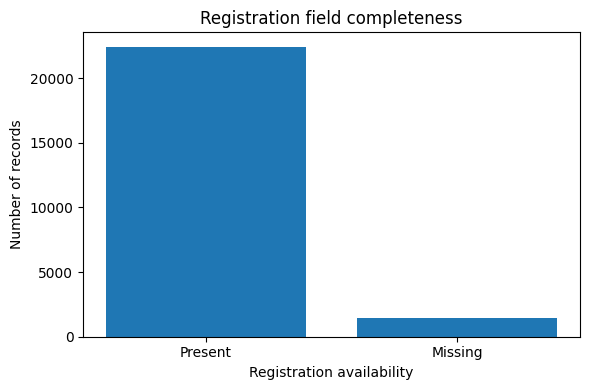

Out of 23,852 records, 22,418 (94.0%) contain a registration code, while 1,434 (6.0%) are missing it.
This suggests that registration is useful mainly as an identification field and only marginally informative for aggregate accident analysis.


In [195]:
# Registration field: completeness and basic structure
registration_series = df["registration"].copy()

# Standardize blanks and placeholder-like values
registration_clean = (
    registration_series.astype("string")
    .str.strip()
    .replace(["", "nan", "None", "unknown", "Unknown"], pd.NA)
)

registration_missing = registration_clean.isna().sum()
registration_present = registration_clean.notna().sum()
registration_total = len(registration_clean)

registration_summary = pd.DataFrame({
    "Count": [registration_present, registration_missing],
    "Percentage": [
        round(registration_present / registration_total * 100, 2),
        round(registration_missing / registration_total * 100, 2)
    ]
}, index=["Present", "Missing"])

display(registration_summary)

plt.figure(figsize=(6, 4))
plt.bar(registration_summary.index, registration_summary["Count"])
plt.title("Registration field completeness")
plt.ylabel("Number of records")
plt.xlabel("Registration availability")
plt.tight_layout()
plt.show()

print(
    f"Out of {registration_total:,} records, "
    f"{registration_present:,} ({registration_present / registration_total:.1%}) "
    f"contain a registration code, while "
    f"{registration_missing:,} ({registration_missing / registration_total:.1%}) are missing it."
)

print(
    "This suggests that registration is useful mainly as an identification field "
    "and only marginally informative for aggregate accident analysis."
)

#### Most common registration prefixes

Registration codes often begin with a prefix that reflects a national or administrative allocation pattern.
This is not a core safety variable, but a quick overview of the most frequent prefixes helps describe the structure of the dataset more completely.

,Registration prefix,Count
0,N,3350
1,CCCP,977
2,HK,341
3,RA,334
4,NC,333
5,CCCP-L,319
6,T,174
7,B,171
8,A,167
9,CP,163


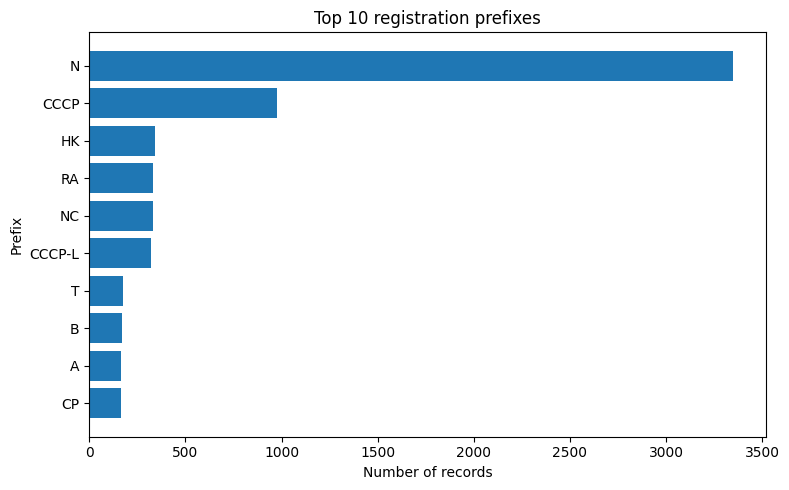

The distribution of registration prefixes shows that this field follows recurrent identification patterns. These prefixes are useful for describing the structure of the dataset, but they should not be interpreted as direct indicators of accident risk.


In [196]:
# Extract the leading registration prefix to inspect recurring identification patterns.
# These prefixes are descriptive metadata, not safety indicators.
registration_prefix = (
    registration_clean.dropna()
    .str.upper()
    .str.extract(r"^([A-Z]+(?:-[A-Z]+)?)")[0]
)

top_registration_prefixes = (
    registration_prefix.dropna()
    .value_counts()
    .head(10)
    .reset_index()
)

top_registration_prefixes.columns = ["Registration prefix", "Count"]

display(top_registration_prefixes)

plt.figure(figsize=(8, 5))
plt.barh(
    top_registration_prefixes["Registration prefix"][::-1],
    top_registration_prefixes["Count"][::-1]
)
plt.title("Top 10 registration prefixes")
plt.xlabel("Number of records")
plt.ylabel("Prefix")
plt.tight_layout()
plt.show()

print(
    "The distribution of registration prefixes shows that this field follows recurrent identification patterns. "
    "These prefixes are useful for describing the structure of the dataset, but they should not be interpreted as direct indicators of accident risk."
)

**Registration prefixes — interpretation**

The chart shows that a limited number of registration prefixes appear much more frequently than others, indicating recurring identification patterns in the dataset.

Overall, this distribution is useful for describing the basic structure of the `registration` field, but it should not be interpreted as a direct indicator of accident risk.

**Interpretation note**

Registration prefixes mainly reflect aircraft registration systems rather than safety performance. For this reason, they can support descriptive exploration of the dataset, but not causal or risk-adjusted conclusions.

In [197]:
# Final summary table of key insights
# This table condenses the main findings of the project into a single
# reader-friendly view to support the final conclusions section.

top_country_accidents = country_counts.idxmax()
top_country_accidents_n = int(country_counts.max())
top_country_accidents_share = round((country_counts.max() / country_total) * 100, 2)

top_country_fatalities_name = country_fatalities.iloc[0]["country_clean"]
top_country_fatalities_n = int(country_fatalities.iloc[0]["fatalities_clean"])

top_weekday_name = weekday_counts.idxmax()
top_weekday_n = int(weekday_counts.max())
top_weekday_share = round((weekday_counts.max() / weekday_total) * 100, 2)

peak_decade_accidents = int(decade_trends["accidents"].idxmax())
peak_decade_accidents_n = int(decade_trends["accidents"].max())

peak_decade_fatalities = int(decade_trends["total_fatalities"].idxmax())
peak_decade_fatalities_n = int(decade_trends["total_fatalities"].max())

top_family_name = family_summary_robust["total_fatalities"].idxmax()
top_family_fatalities = int(family_summary_robust.loc[top_family_name, "total_fatalities"])

before_911_avg = float(comparison_911["avg_accidents_per_year"].iloc[0])
after_911_avg = float(comparison_911["avg_accidents_per_year"].iloc[1])
change_911_pct = round(((after_911_avg - before_911_avg) / before_911_avg) * 100, 2)

military_share = round((df["record_scope"].eq("Military").mean()) * 100, 2)

final_insights_summary = pd.DataFrame({
    "Insight": [
        "Country ranking — highest number of recorded accidents",
        "Supporting comparison — highest total fatalities by country",
        "Weekday distribution — most frequent day",
        "Historical peak decade by recorded accidents",
        "Historical peak decade by total fatalities",
        "Robust family-level view — highest total fatalities",
        "Pre-/post-9/11 comparison — average accidents per year",
        "Share of records classified as Military"
    ],
    "Key result": [
        f"{top_country_accidents} ({top_country_accidents_n:,}; {top_country_accidents_share}%)",
        f"{top_country_fatalities_name} ({top_country_fatalities_n:,} fatalities)",
        f"{top_weekday_name} ({top_weekday_n:,}; {top_weekday_share}%)",
        f"{peak_decade_accidents}s ({peak_decade_accidents_n:,} accidents)",
        f"{peak_decade_fatalities}s ({peak_decade_fatalities_n:,} fatalities)",
        f"{top_family_name} ({top_family_fatalities:,} fatalities)",
        f"{change_911_pct:+.2f}% ({before_911_avg:.2f} → {after_911_avg:.2f})",
        f"{military_share}%"
    ],
    "Interpretation": [
        "Highest concentration of country-attributed accident records in the dataset.",
        "Largest cumulative human toll among countries with known fatalities.",
        "Most frequent weekday in records with a valid full date.",
        "Historical peak in accident frequency across decades.",
        "Historical peak in cumulative human impact across decades.",
        "Aircraft family most associated with cumulative fatalities after robustness filters.",
        "Using two comparable 10-year windows, the post-9/11 period shows a lower average number of recorded accidents per year.",
        "Helps contextualize the influence of military activity on long-run accident patterns."
    ]
})

display(
    final_insights_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("max-width", "380px")]}
    ])
)

Insight,Key result,Interpretation
Country ranking — highest number of recorded accidents,"United States (4,376; 19.43%)",Highest concentration of country-attributed accident records in the dataset.
Supporting comparison — highest total fatalities by country,"United States (19,305 fatalities)",Largest cumulative human toll among countries with known fatalities.
Weekday distribution — most frequent day,"Friday (3,609; 15.49%)",Most frequent weekday in records with a valid full date.
Historical peak decade by recorded accidents,"1940s (5,768 accidents)",Historical peak in accident frequency across decades.
Historical peak decade by total fatalities,"1970s (22,087 fatalities)",Historical peak in cumulative human impact across decades.
Robust family-level view — highest total fatalities,"Boeing 737 (5,853 fatalities)",Aircraft family most associated with cumulative fatalities after robustness filters.
Pre-/post-9/11 comparison — average accidents per year,-11.94% (242.10 → 213.20),"Using two comparable 10-year windows, the post-9/11 period shows a lower average number of recorded accidents per year."
Share of records classified as Military,34.23%,Helps contextualize the influence of military activity on long-run accident patterns.


## Final conclusions

This analysis of aviation accidents from 1919 to 2023 shows that recorded air disasters are not evenly distributed across countries, time periods, or operational contexts. Instead, the dataset reveals clear concentration patterns shaped by historical events, military activity, operator presence, and differences in record coverage over time.

Several key findings emerge from the project. First, country-level results show a strong concentration of recorded accidents in a limited number of countries, with the United States ranking first both in number of recorded accidents and in total fatalities. This does not mean that these countries are necessarily less safe, but it does confirm that the dataset is geographically concentrated rather than evenly distributed. Second, weekday patterns are not perfectly uniform, although the practical difference remains moderate: Friday is the most frequent day in the dataset, while Sunday records the lowest share. This suggests a descriptive imbalance in recorded events, not a strong standalone indicator of real-world aviation risk.

Third, the pre-/post-9/11 comparison based on two symmetric 10-year windows shows a lower average number of recorded accidents per year after September 11, 2001, decreasing from 242.1 to 213.2 (-11.9%). Fourth, long-term historical trends must be interpreted carefully because the largest spike in accident frequency occurs in the 1940s and is strongly influenced by military-classified records, with the overall annual peak reaching 1504 accidents in 1944 and the military peak alone reaching 1410 in the same year. Fifth, severity does not always move in parallel with event frequency: while the 1940s dominate in number of recorded accidents, total fatalities peak in the 1970s (22,087), confirming that accident counts and human impact should always be interpreted together.

The project also shows that aircraft-level analysis is more informative when the `type` field is aggregated into broader families rather than interpreted only at raw label level. In this more robust family-based view, the Boeing 737 is associated with the highest cumulative fatality total in the dataset. By contrast, operator-level results are useful for describing cumulative burden, but they should not be used to rank the “safest” operators, because the dataset does not include key exposure variables such as fleet size, flight volume, or flight hours.

At the same time, the analysis has important methodological limits. Country totals, operator totals, and weekday distributions are descriptive counts of recorded events, not exposure-adjusted risk measures. Historical comparisons are also affected by uneven data completeness, especially in older decades and for variables such as fatalities. For this reason, the notebook supports strong descriptive insights, but more cautious causal or performance-based conclusions.

From the perspective of the IASS, the main value of this project is that it identifies where accident concentration is highest, how accident patterns changed over time, and which contexts are more strongly associated with severe outcomes. These results can support historical monitoring, exploratory safety assessment, and priority-setting for further investigation, especially when combined with additional operational and exposure data.

Overall, the analysis suggests a long-term reduction in recorded accident burden, while also confirming that aviation accident patterns remain deeply shaped by historical context, military activity, operator concentration, and data structure. The dataset is therefore highly valuable for exploratory safety analysis, provided that conclusions are interpreted with appropriate methodological caution.